In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
# 1. Load the latent vectors from your trained model
experiment_dir = 'examples/ADNI_1_L_No_MCI/minimal_eikonal_gmm'
checkpoint = 'latest'

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f'Loaded latent vectors with shape: {X.shape}')


Loaded latent vectors with shape: (696, 256)


In [3]:
# 2. Load the filenames of the meshes and labels
import json

with open(os.path.join(experiment_dir, 'specs.json'), 'r') as f:
    specs = json.load(f)

mesh_root = specs.get('DataSourceMesh', specs['DataSource'])
train_split_file = specs.get('TrainSplit')
test_split_file = specs.get('TestSplit')
labels_path = os.path.join(mesh_root, 'labels.pt')

def load_split(path):
    if not path:
        return []
    with open(path, 'r') as f:
        return json.load(f)

train_split = load_split(train_split_file)
test_split = load_split(test_split_file)

# Combine train + test (unique), but fall back if sizes mismatch latent vectors
split_list = []
seen = set()
for name in train_split + test_split:
    if name not in seen:
        split_list.append(name)
        seen.add(name)

valid_filenames = split_list
if X.shape[0] != len(valid_filenames):
    if len(train_split) == X.shape[0]:
        print('Latent count matches train split; using train split only.')
        valid_filenames = train_split
    else:
        print('Warning: latent count does not match split sizes.')

print(f'Train split: {len(train_split)}')
print(f'Test split: {len(test_split)}')
print(f'Using {len(valid_filenames)} filenames for label matching')

mesh_params = []
if os.path.exists(labels_path):
    print(f'Loading labels from {labels_path}')
    all_labels = torch.load(labels_path, map_location='cpu')
    label_map = all_labels
    if not isinstance(all_labels, dict):
        if hasattr(all_labels, '__len__') and len(all_labels) == len(valid_filenames):
            label_map = {}
            for idx, filename in enumerate(valid_filenames):
                base_name = os.path.splitext(os.path.basename(filename))[0]
                label_map[base_name] = all_labels[idx]
        else:
            print('Warning: labels are not a dict and length does not match filenames; skipping label lookup.')
            label_map = {}

    for filename in valid_filenames:
        base_name = os.path.splitext(os.path.basename(filename))[0]
        params = {
            'diagnosis': -1,
            'age': float('nan'),
            'sex': -1,
            'volume': float('nan'),
        }
        if base_name in label_map:
            label = label_map[base_name]
            params['diagnosis'] = int(label[0].item())
            params['age'] = float(label[1].item())
            params['sex'] = int(label[2].item())
            params['volume'] = float(label[3].item())
        else:
            print(f'Warning: No label found for {base_name}')
        mesh_params.append(params)
else:
    print(f'labels.pt not found at {labels_path}')


Latent count matches train split; using train split only.
Train split: 696
Test split: 77
Using 696 filenames for label matching
Loading labels from /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/labels.pt


In [4]:
# Extract parameters for visualization
diagnosis = np.array([p.get('diagnosis', -1) for p in mesh_params])
age = np.array([p.get('age', float('nan')) for p in mesh_params], dtype=float)
sex = np.array([p.get('sex', -1) for p in mesh_params])
volume = np.array([p.get('volume', float('nan')) for p in mesh_params], dtype=float)

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((diagnosis, age, sex, volume))
factor_names = ['diagnosis', 'age', 'sex', 'volume']


In [5]:
# AD prediction imports (independent cell)
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


In [8]:
# Predict AD (diagnosis == 1) from 256D latent vectors using a small MLP
mask = diagnosis >= 0
X_valid = X[mask]
y = (diagnosis[mask] == 1).astype(np.int64)

if X_valid.shape[1] != 256:
    print(f'Warning: expected 256D latent, got {X_valid.shape[1]}D')

if len(np.unique(y)) < 2:
    raise ValueError('Need at least two classes for AD prediction. Check labels.')

X_train, X_val, y_train, y_val = train_test_split(
    X_valid, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val).float(),
    torch.from_numpy(y_val)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2),
).to(device)

class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (2.0 * class_counts), dtype=torch.float32, device=device
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(200):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

model.eval()
with torch.no_grad():
    val_logits = []
    val_targets = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        val_logits.append(logits.cpu())
        val_targets.append(yb)

val_logits = torch.cat(val_logits, dim=0)
val_targets = torch.cat(val_targets, dim=0).numpy()
val_probs = torch.softmax(val_logits, dim=1)[:, 1].numpy()
val_preds = (val_probs >= 0.5).astype(np.int64)

acc = accuracy_score(val_targets, val_preds)
auc = roc_auc_score(val_targets, val_probs)
print(f'Validation accuracy: {acc:.3f}  AUROC: {auc:.3f}')
print(classification_report(val_targets, val_preds, digits=3))


Validation accuracy: 0.886  AUROC: 0.954
              precision    recall  f1-score   support

           0      0.889     0.911     0.900        79
           1      0.881     0.852     0.867        61

    accuracy                          0.886       140
   macro avg      0.885     0.882     0.883       140
weighted avg      0.886     0.886     0.885       140



In [9]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [10]:
# 3.1. PCA
print('Applying PCA...')
pca = PCA(n_components=4)
Y_pca = pca.fit_transform(X)
results['PCA'] = Y_pca
transformed_latents['PCA'] = Y_pca
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

# check if volume is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA
best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions
for n_neighbors in range(300, 320, 10):
    for n_components in [4]:
        try:
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)
            #Y_hlle_ica = Z

            correlations = []
            mask = diagnosis >= 0
            for comp in range(n_components):
                if np.any(mask):
                    corr = np.corrcoef(Y_hlle_ica[mask, comp], diagnosis[mask])[0, 1]
                else:
                    corr = float('nan')
                correlations.append(corr)
            print(correlations)

            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]

            print(f'n_neighbors: {n_neighbors}, n_components: {n_components}, '
                  f'best component correlation: {best_component_corr:.4f}')

            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)

        except Exception as e:
            print(f'Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}')

if best_Y_hlle_ica is not None:
    print('\nBest parameter set:')
    print(f'n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}')
    results['HLLE+ICA'] = best_Y_hlle_ica
    transformed_latents['HLLE+ICA'] = best_Y_hlle_ica
else:
    print('No valid HLLE+ICA transformation found.')


Applying PCA...
PCA explained variance ratio: 0.2770
Correlation between distance from origin and volume: -0.0560


[0.22469468594198128, 0.03860157064989385, 0.08272347864391387, -0.6089075449428902]
n_neighbors: 300, n_components: 4, best component correlation: -0.6089
[0.2040531446576737, -0.01143981734256703, 0.6191941322387329, 0.2297502053005961]
n_neighbors: 310, n_components: 4, best component correlation: 0.6192

Best parameter set:
n_neighbors: 310, n_components: 4, best component: 2 best correlation: 0.6192


In [11]:
# 3.3. NMF
print('Applying NMF...')
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

for n_components in [4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        W = nmf.fit_transform(X_offset)

        correlations = []
        mask = diagnosis >= 0
        for comp in range(n_components):
            if np.any(mask):
                corr = np.corrcoef(W[mask, comp], diagnosis[mask])[0, 1]
            else:
                corr = float('nan')
            correlations.append(corr)

        best_component_corr = max(correlations, key=abs)
        print(f'n_components: {n_components}, best component correlation (diagnosis): {best_component_corr:.4f}')

        if best_corr_nmf is None or abs(best_component_corr) > abs(best_corr_nmf):
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components

    except Exception as e:
        print(f'NMF failed for n_components: {n_components} due to: {e}')

if best_W_nmf is not None:
    results['NMF'] = best_W_nmf
    transformed_latents['NMF'] = best_W_nmf


Applying NMF...
n_components: 4, best component correlation (diagnosis): 0.6414


In [12]:
# 3.4. Factor Analysis
print('Applying Factor Analysis...')
fa = FactorAnalysis(n_components=4, random_state=42)
Y_fa = fa.fit_transform(X)
results['FA'] = Y_fa
transformed_latents['FA'] = Y_fa

center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_Y_fa = distances
distances_all.append(distances)


Applying Factor Analysis...
Correlation between distance from origin and volume: -0.0542


In [13]:
# 3.5. ICA
print('Applying ICA...')
ica = FastICA(n_components=4, random_state=42)
Y_ica = ica.fit_transform(X)
results['ICA'] = Y_ica
transformed_latents['ICA'] = Y_ica

center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_Y_ica = distances
distances_all.append(distances)


Applying ICA...
Correlation between distance from origin and volume: -0.0430


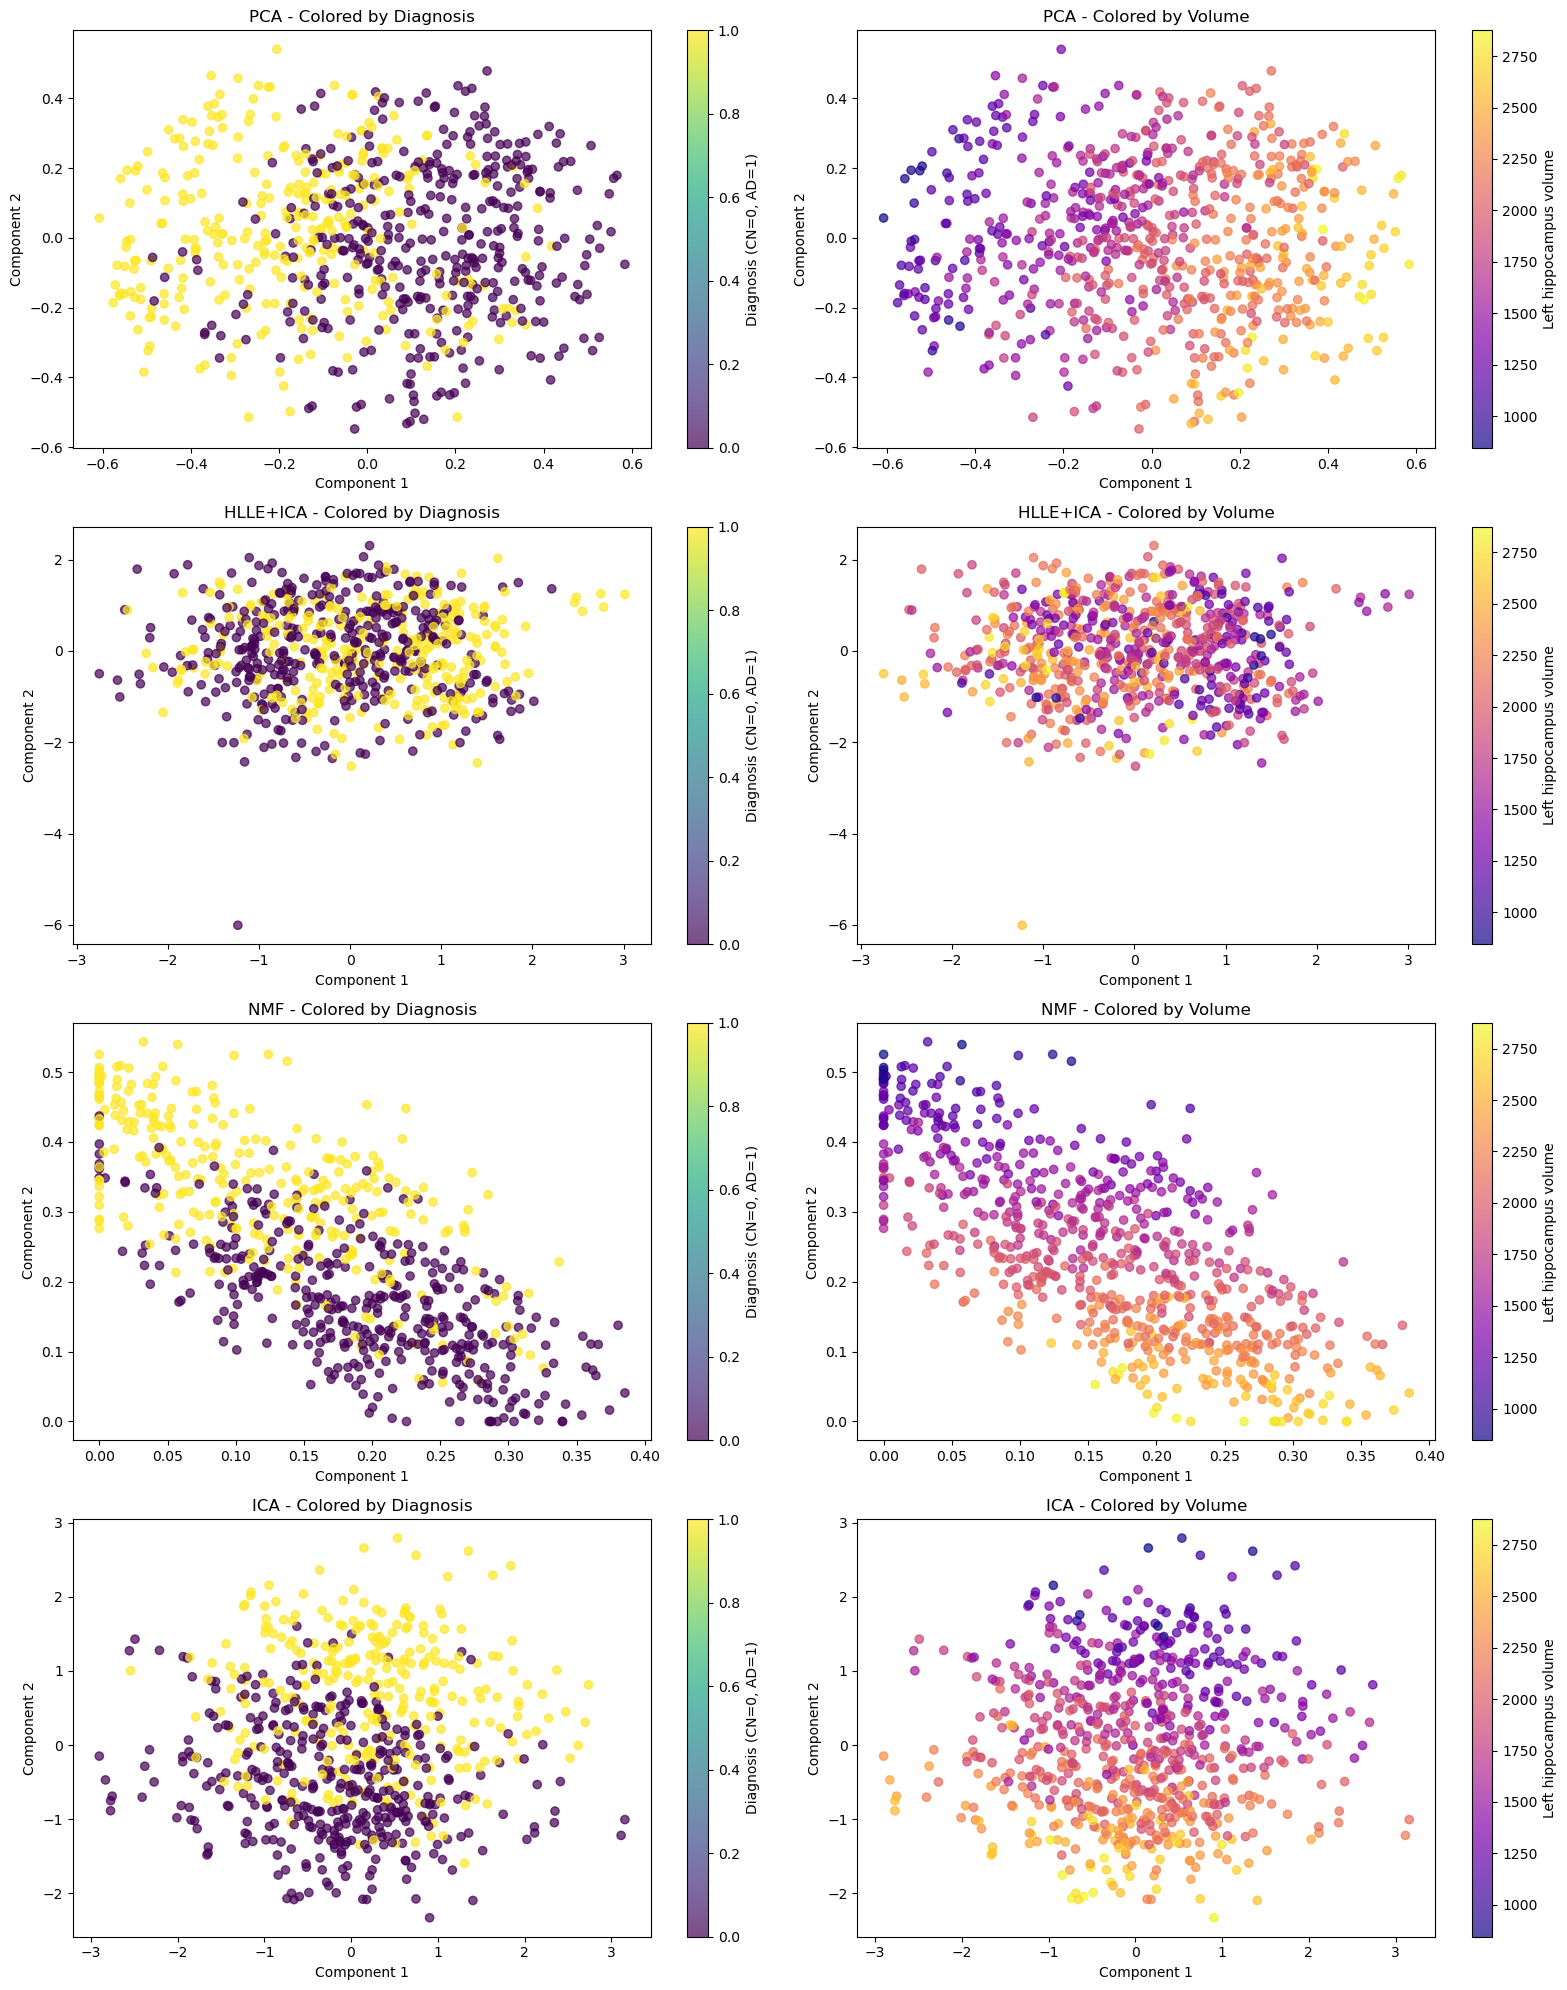

In [14]:
# 4. Visualize results
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

techniques = ['PCA', 'HLLE+ICA', 'NMF', 'ICA']
for i, technique in enumerate(techniques):
    if np.all(results[technique] == 0):
        continue

    scatter = axes[i, 0].scatter(results[technique][:, 0], results[technique][:, 1],
                                c=diagnosis, cmap='viridis', alpha=0.7)
    axes[i, 0].set_title(f'{technique} - Colored by Diagnosis')
    axes[i, 0].set_xlabel('Component 1')
    axes[i, 0].set_ylabel('Component 2')
    plt.colorbar(scatter, ax=axes[i, 0], label='Diagnosis (CN=0, AD=1)')

    mask = np.isfinite(volume)
    scatter = axes[i, 1].scatter(results[technique][mask, 0], results[technique][mask, 1],
                                c=volume[mask], cmap='plasma', alpha=0.7)
    axes[i, 1].set_title(f'{technique} - Colored by Volume')
    axes[i, 1].set_xlabel('Component 1')
    axes[i, 1].set_ylabel('Component 2')
    plt.colorbar(scatter, ax=axes[i, 1], label='Left hippocampus volume')

plt.tight_layout()
plt.show()


In [15]:
# 5. Correlation Analysis
print('\nCorrelation Analysis:')
for technique in techniques:
    if np.all(results[technique] == 0):
        continue

    print(f'\n{technique} Analysis:')
    num_components = results[technique].shape[1]
    if np.any(diagnosis >= 0):
        mask = diagnosis >= 0
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], diagnosis[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with diagnosis: {corr:.4f}')
    if np.any(np.isfinite(age)):
        mask = np.isfinite(age)
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], age[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with age: {corr:.4f}')
    if np.any(sex >= 0):
        mask = sex >= 0
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], sex[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with sex: {corr:.4f}')
    if np.any(np.isfinite(volume)):
        mask = np.isfinite(volume)
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], volume[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with volume: {corr:.4f}')



Correlation Analysis:

PCA Analysis:
Component 1 correlation with diagnosis: -0.5795
Component 2 correlation with diagnosis: 0.0888
Component 3 correlation with diagnosis: -0.2887
Component 4 correlation with diagnosis: -0.1252
Component 1 correlation with age: -0.2202
Component 2 correlation with age: 0.0050
Component 3 correlation with age: -0.0373
Component 4 correlation with age: 0.0974
Component 1 correlation with sex: -0.0451
Component 2 correlation with sex: 0.3493
Component 3 correlation with sex: -0.1216
Component 4 correlation with sex: -0.1614
Component 1 correlation with volume: 0.8679
Component 2 correlation with volume: -0.2082
Component 3 correlation with volume: 0.4186
Component 4 correlation with volume: 0.0763

HLLE+ICA Analysis:
Component 1 correlation with diagnosis: 0.2041
Component 2 correlation with diagnosis: -0.0114
Component 3 correlation with diagnosis: 0.6192
Component 4 correlation with diagnosis: 0.2298
Component 1 correlation with age: 0.1125
Component 2

In [16]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-0.682, Skew=-0.189, Negent=0.064
component_1: Kurt=-0.573, Skew=-0.107, Negent=0.044
component_2: Kurt=-0.150, Skew=-0.161, Negent=0.031
component_3: Kurt=-0.063, Skew=0.155, Negent=0.021

HLLE+ICA Quality Metrics:
component_0: Kurt=-0.448, Skew=-0.046, Negent=0.423
component_1: Kurt=1.036, Skew=-0.459, Negent=0.411
component_2: Kurt=-0.595, Skew=0.186, Negent=0.424
component_3: Kurt=0.156, Skew=0.254, Negent=0.399

NMF Quality Metrics:
component_0: Kurt=-0.804, Skew=-0.025, Negent=0.008
component_1: Kurt=-0.758, Skew=0.225, Negent=0.014
component_2: Kurt=-0.600, Skew=0.036, Negent=0.009
component_3: Kurt=-0.508, Skew=0.217, Negent=0.020

ICA Quality Metrics:
component_0: Kurt=0.239, Skew=0.014, Negent=0.381
component_1: Kurt=-0.642, Skew=0.197, Negent=0.427
component_2: Kurt=-0.672, Skew=-0.010, Negent=0.429
component_3: Kurt=-0.555, Skew=-0.152, Negent=0.422


Projecting individual latent vectors onto learned components...
Projection shapes:
PCA: (696, 4)
ICA: (696, 4)
HLLE+ICA: (696, 2)


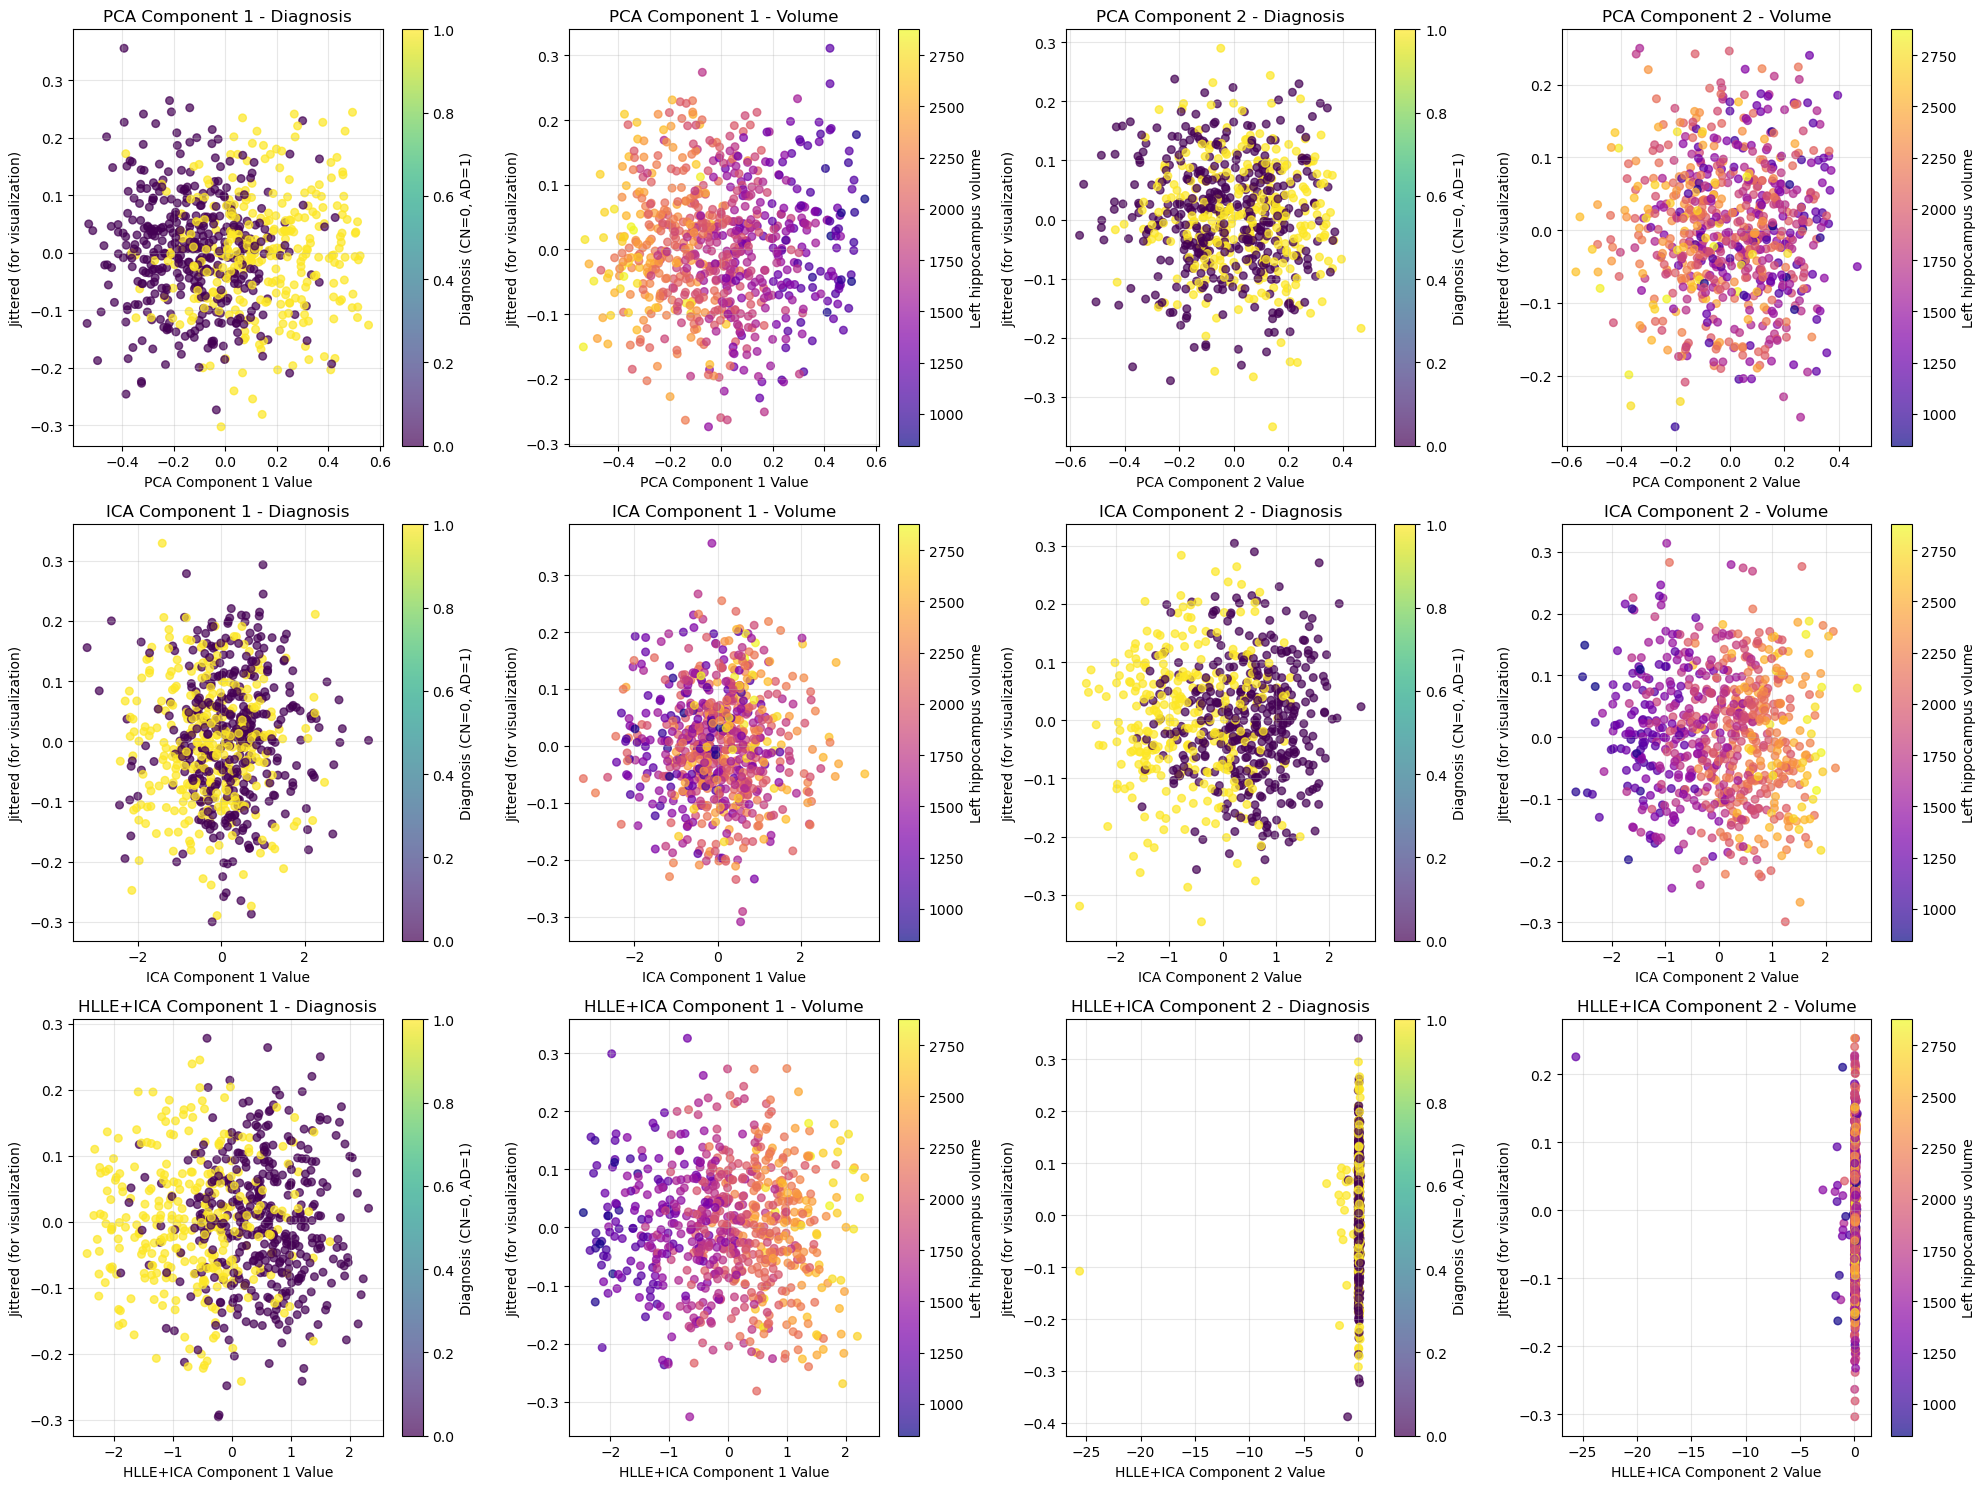

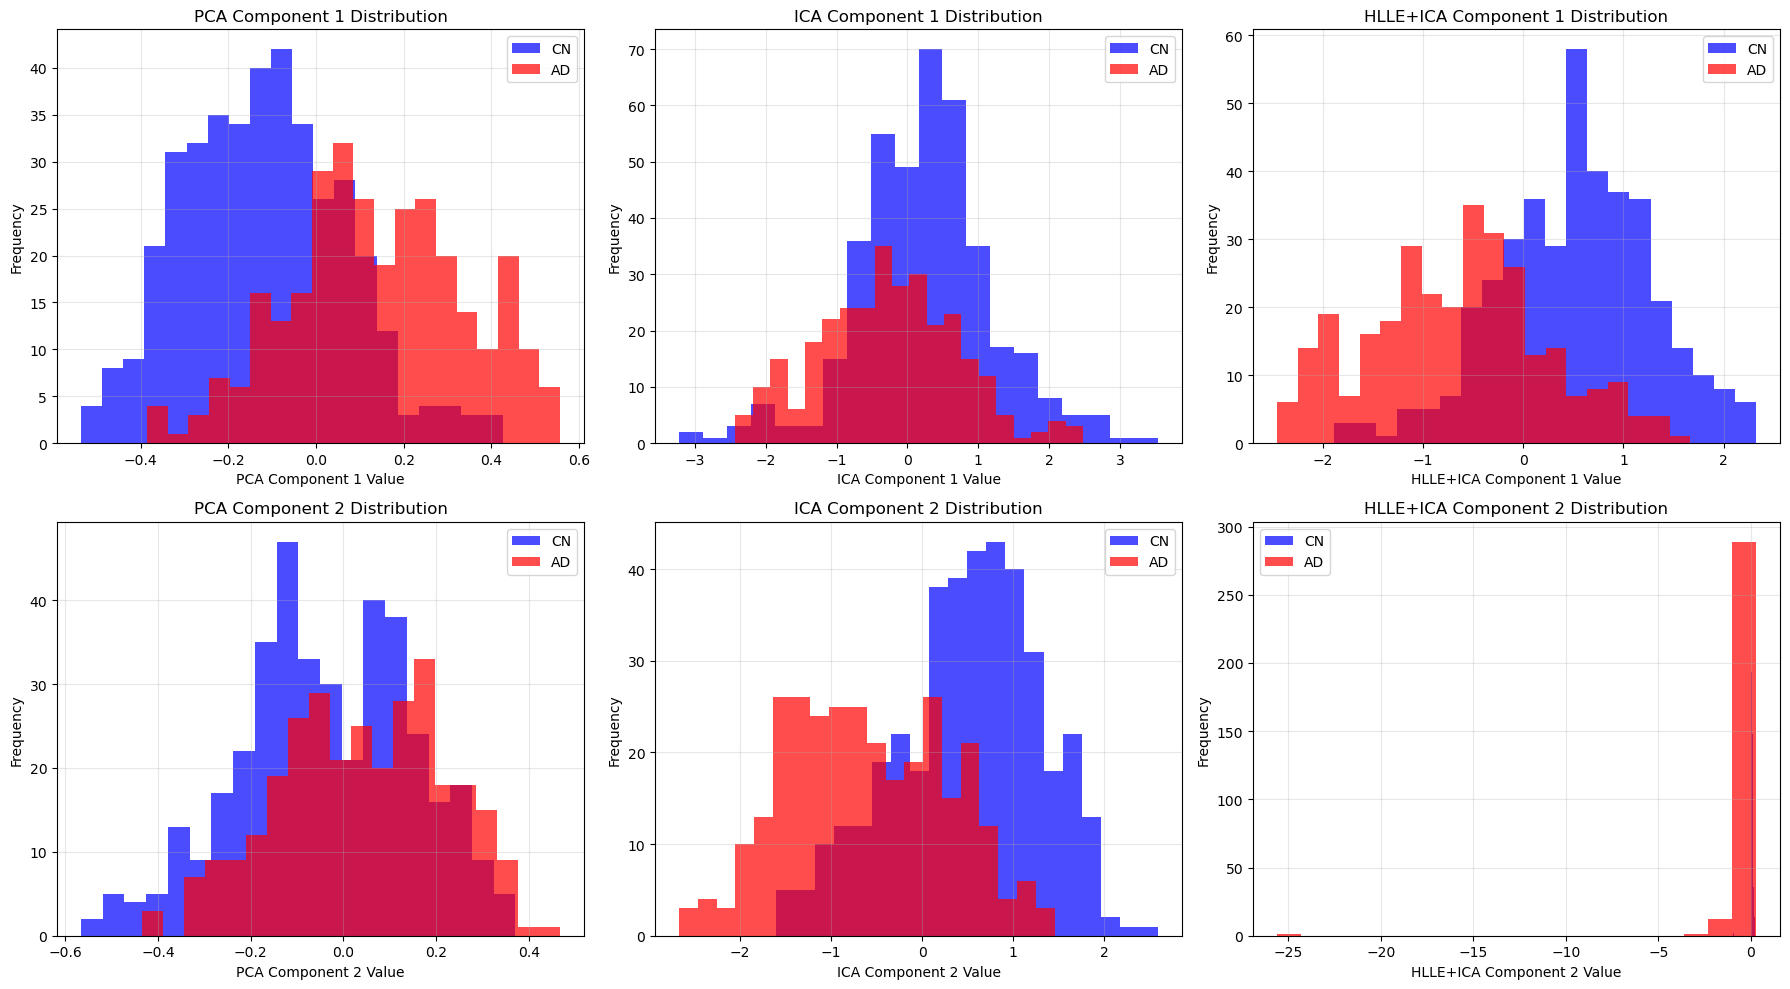

In [35]:
# 9. Project individual latent vectors onto learned components
print('Projecting individual latent vectors onto learned components...')

X_16d = latent_vectors.cpu().numpy()

individual_projections = {}

pca_components = pca.components_
pca_projections = X_16d @ pca_components.T
individual_projections['PCA'] = pca_projections

ica_components = ica.components_
ica_projections = X_16d @ ica_components.T
individual_projections['ICA'] = ica_projections

if best_Y_hlle_ica is not None:
    best_n_neighbors = best_params[0]
    hlle_for_projection = LocallyLinearEmbedding(n_neighbors=best_n_neighbors,
                                                 n_components=2,
                                                 method='hessian',
                                                 eigen_solver='dense')
    hlle_for_projection.fit(X)
    hlle_transformed = hlle_for_projection.transform(X_16d)
    ica_after_hlle = FastICA(n_components=2, random_state=42)
    hlle_train_transformed = hlle_for_projection.transform(X)
    ica_after_hlle.fit(hlle_train_transformed)
    hlle_ica_projections = ica_after_hlle.transform(hlle_transformed)
    individual_projections['HLLE+ICA'] = hlle_ica_projections
else:
    individual_projections['HLLE+ICA'] = None

print('Projection shapes:')
for method, proj in individual_projections.items():
    if proj is not None:
        print(f'{method}: {proj.shape}')

# 10. Visualize projections of first two components against labels
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

methods = ['PCA', 'ICA', 'HLLE+ICA']
for i, method in enumerate(methods):
    if individual_projections[method] is None:
        for j in range(4):
            axes[i, j].text(0.5, 0.5, f'{method}\nFailed', ha='center', va='center')
        continue

    projections = individual_projections[method]

    jittered_y1 = np.random.normal(0, 0.1, len(projections))
    scatter1 = axes[i, 0].scatter(projections[:, 0], jittered_y1, c=diagnosis,
                                 cmap='viridis', alpha=0.7, s=30)
    axes[i, 0].set_xlabel(f'{method} Component 1 Value')
    axes[i, 0].set_ylabel('Jittered (for visualization)')
    axes[i, 0].set_title(f'{method} Component 1 - Diagnosis')
    axes[i, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[i, 0], label='Diagnosis (CN=0, AD=1)')

    vol_mask = np.isfinite(volume)
    jittered_y2 = np.random.normal(0, 0.1, np.sum(vol_mask))
    scatter2 = axes[i, 1].scatter(projections[vol_mask, 0], jittered_y2, c=volume[vol_mask],
                                 cmap='plasma', alpha=0.7, s=30)
    axes[i, 1].set_xlabel(f'{method} Component 1 Value')
    axes[i, 1].set_ylabel('Jittered (for visualization)')
    axes[i, 1].set_title(f'{method} Component 1 - Volume')
    axes[i, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[i, 1], label='Left hippocampus volume')

    if projections.shape[1] > 1:
        jittered_y3 = np.random.normal(0, 0.1, len(projections))
        scatter3 = axes[i, 2].scatter(projections[:, 1], jittered_y3, c=diagnosis,
                                     cmap='viridis', alpha=0.7, s=30)
        axes[i, 2].set_xlabel(f'{method} Component 2 Value')
        axes[i, 2].set_ylabel('Jittered (for visualization)')
        axes[i, 2].set_title(f'{method} Component 2 - Diagnosis')
        axes[i, 2].grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=axes[i, 2], label='Diagnosis (CN=0, AD=1)')

        jittered_y4 = np.random.normal(0, 0.1, np.sum(vol_mask))
        scatter4 = axes[i, 3].scatter(projections[vol_mask, 1], jittered_y4, c=volume[vol_mask],
                                     cmap='plasma', alpha=0.7, s=30)
        axes[i, 3].set_xlabel(f'{method} Component 2 Value')
        axes[i, 3].set_ylabel('Jittered (for visualization)')
        axes[i, 3].set_title(f'{method} Component 2 - Volume')
        axes[i, 3].grid(True, alpha=0.3)
        plt.colorbar(scatter4, ax=axes[i, 3], label='Left hippocampus volume')
    else:
        axes[i, 2].text(0.5, 0.5, 'Only 1\nComponent', ha='center', va='center')
        axes[i, 3].text(0.5, 0.5, 'Only 1\nComponent', ha='center', va='center')

plt.tight_layout()
plt.savefig('component_projections_vs_labels_both_components.png', dpi=300, bbox_inches='tight')
plt.show()

# 13. Enhanced histogram visualization - both components
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, method in enumerate(methods):
    if individual_projections[method] is None:
        axes[0, i].text(0.5, 0.5, f'{method}\nFailed', ha='center', va='center')
        axes[1, i].text(0.5, 0.5, f'{method}\nFailed', ha='center', va='center')
        continue

    projections = individual_projections[method]
    cn_mask = diagnosis == 0
    ad_mask = diagnosis == 1

    first_component = projections[:, 0]
    axes[0, i].hist(first_component[cn_mask], alpha=0.7, label='CN', bins=20, color='blue')
    axes[0, i].hist(first_component[ad_mask], alpha=0.7, label='AD', bins=20, color='red')
    axes[0, i].set_xlabel(f'{method} Component 1 Value')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].set_title(f'{method} Component 1 Distribution')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    if projections.shape[1] > 1:
        second_component = projections[:, 1]
        axes[1, i].hist(second_component[cn_mask], alpha=0.7, label='CN', bins=20, color='blue')
        axes[1, i].hist(second_component[ad_mask], alpha=0.7, label='AD', bins=20, color='red')
        axes[1, i].set_xlabel(f'{method} Component 2 Value')
        axes[1, i].set_ylabel('Frequency')
        axes[1, i].set_title(f'{method} Component 2 Distribution')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    else:
        axes[1, i].text(0.5, 0.5, 'Only 1\nComponent', ha='center', va='center')

plt.tight_layout()
plt.savefig('component_distributions_both_components.png', dpi=300, bbox_inches='tight')
plt.show()


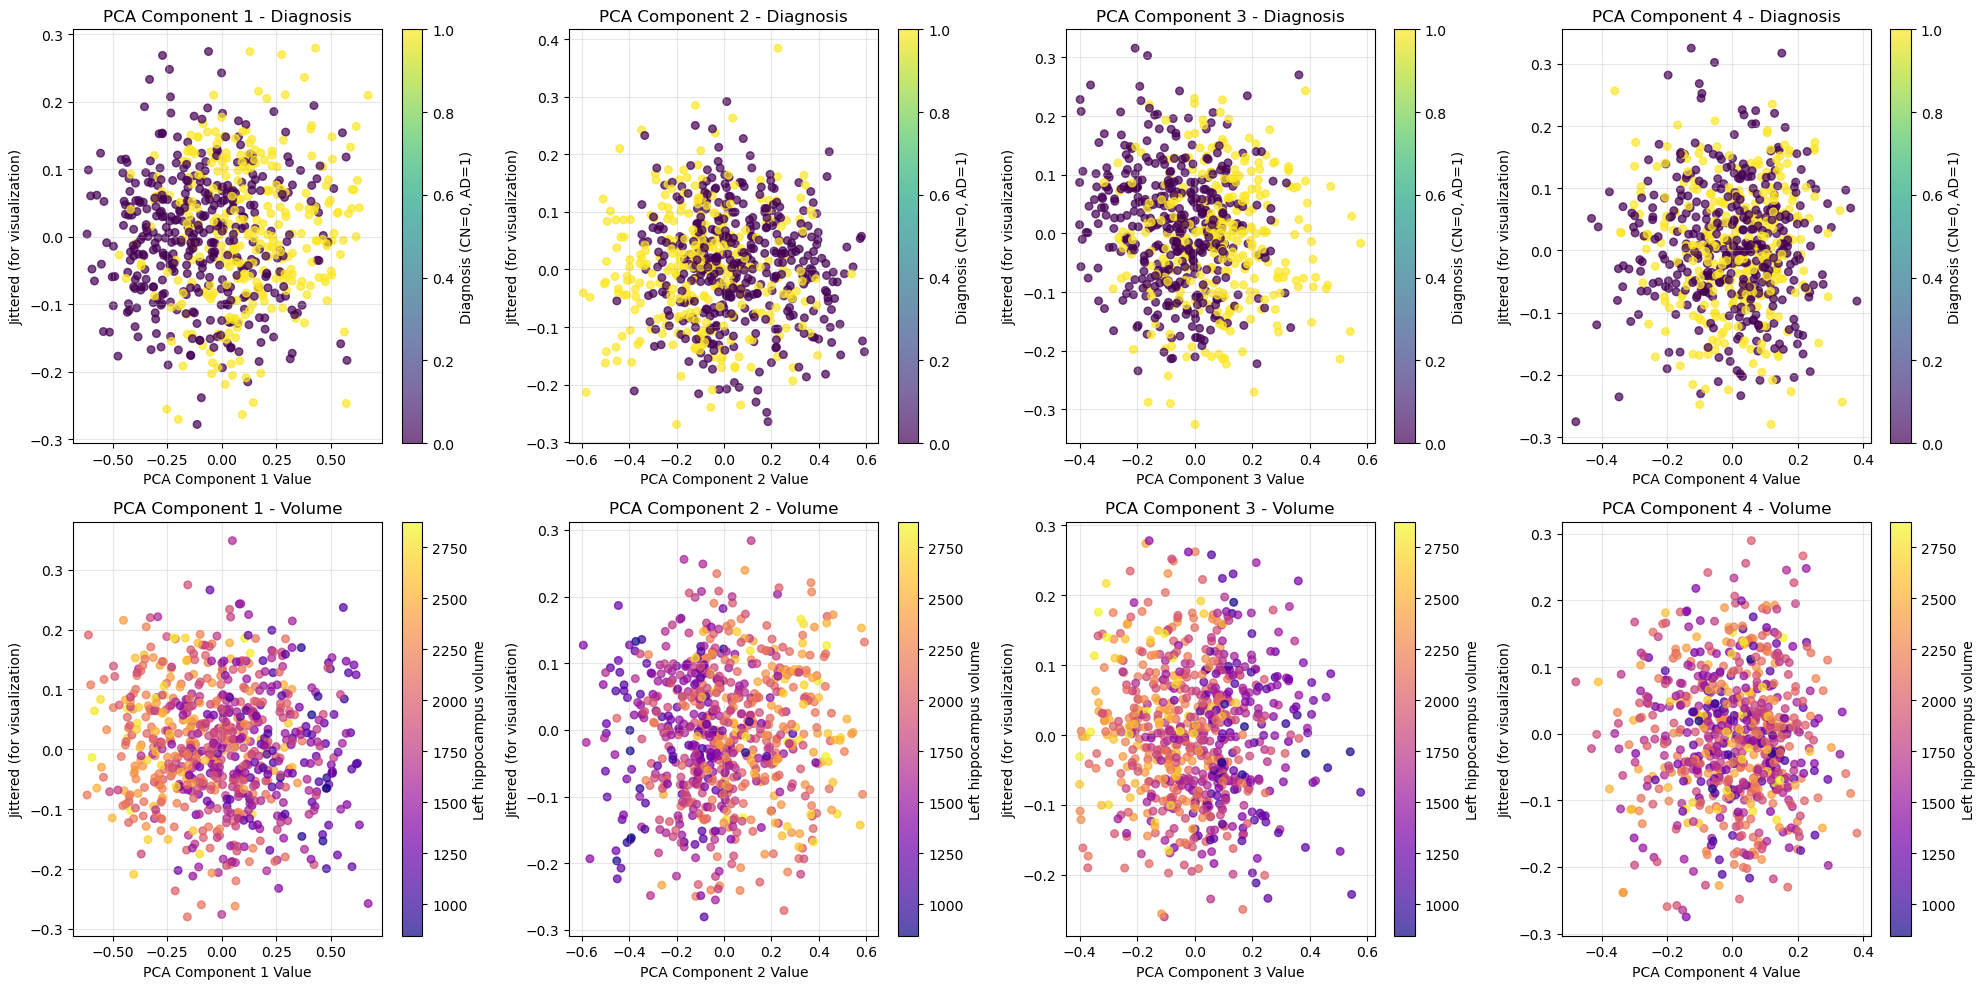

In [86]:
# Plot all 4 PCA components for diagnosis and volume
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

pca_results = results['PCA']

for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[0, i].scatter(pca_results[:, i], jittered_y, c=diagnosis,
                                cmap='viridis', alpha=0.7, s=30)
    axes[0, i].set_xlabel(f'PCA Component {i+1} Value')
    axes[0, i].set_ylabel('Jittered (for visualization)')
    axes[0, i].set_title(f'PCA Component {i+1} - Diagnosis')
    axes[0, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, i], label='Diagnosis (CN=0, AD=1)')

for i in range(4):
    mask = np.isfinite(volume)
    jittered_y = np.random.normal(0, 0.1, np.sum(mask))
    scatter = axes[1, i].scatter(pca_results[mask, i], jittered_y, c=volume[mask],
                                cmap='plasma', alpha=0.7, s=30)
    axes[1, i].set_xlabel(f'PCA Component {i+1} Value')
    axes[1, i].set_ylabel('Jittered (for visualization)')
    axes[1, i].set_title(f'PCA Component {i+1} - Volume')
    axes[1, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, i], label='Left hippocampus volume')

plt.tight_layout()
plt.show()



Analyzing volume encoding across all latent dimensions:
Latent dim 1: volume correlation = -0.0045
Latent dim 2: volume correlation = 0.0132
Latent dim 3: volume correlation = 0.0888
Latent dim 4: volume correlation = 0.0203
Latent dim 5: volume correlation = -0.1289
Latent dim 6: volume correlation = -0.4995
Latent dim 7: volume correlation = 0.0871
Latent dim 8: volume correlation = 0.0586
Latent dim 9: volume correlation = -0.0184
Latent dim 10: volume correlation = -0.2210
Latent dim 11: volume correlation = 0.0114
Latent dim 12: volume correlation = 0.0107
Latent dim 13: volume correlation = -0.0253
Latent dim 14: volume correlation = 0.0228
Latent dim 15: volume correlation = 0.0615
Latent dim 16: volume correlation = -0.0061
Latent dim 17: volume correlation = -0.0105
Latent dim 18: volume correlation = 0.0004
Latent dim 19: volume correlation = 0.0352
Latent dim 20: volume correlation = 0.0063
Latent dim 21: volume correlation = 0.0794
Latent dim 22: volume correlation = 0.011

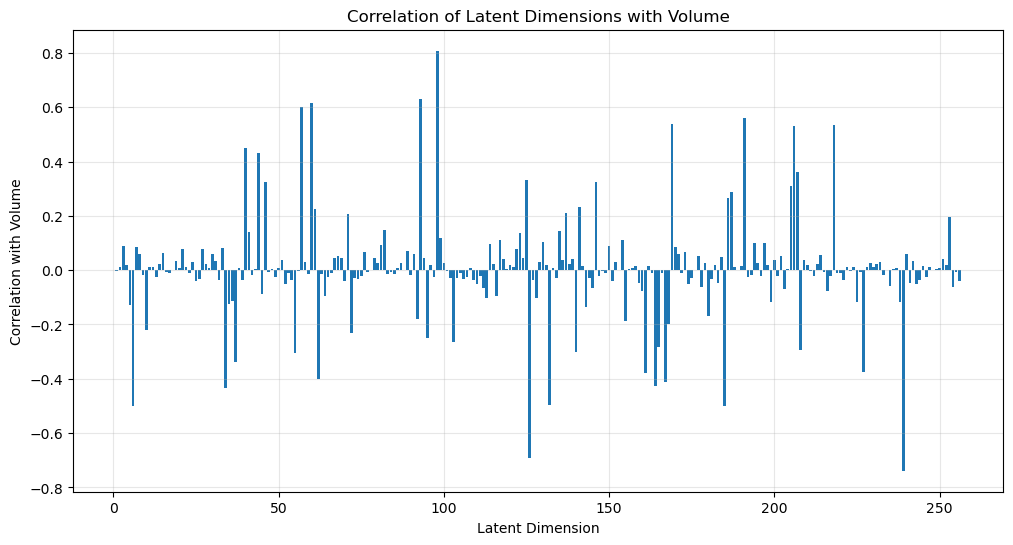

In [17]:
# Test if volume information is distributed across all dimensions
print('\nAnalyzing volume encoding across all latent dimensions:')

latent_volume_correlations = []
mask = np.isfinite(volume)
for dim in range(X.shape[1]):
    if np.any(mask):
        corr = np.corrcoef(X[mask, dim], volume[mask])[0, 1]
    else:
        corr = float('nan')
    latent_volume_correlations.append(corr)
    print(f'Latent dim {dim+1}: volume correlation = {corr:.4f}')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

if np.any(mask):
    lr = LinearRegression()
    lr.fit(X[mask], volume[mask])
    predicted_volumes = lr.predict(X[mask])
    r2 = r2_score(volume[mask], predicted_volumes)
    quality = 'well' if r2 > 0.7 else 'poorly'
    print(f'\nLinear regression R² for predicting volume: {r2:.4f}')
    print(f'This suggests volume information is {quality} encoded in the full latent space')
else:
    print('No finite volume values for linear regression.')

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(latent_volume_correlations) + 1), latent_volume_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Volume')
plt.title('Correlation of Latent Dimensions with Volume')
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
# Add this cell to your notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import seaborn as sns

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use your original 16D latent vectors
X_clustering = X.copy()  # Your original 16D latent vectors

# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionary to store clustering results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)  # Try 2 to 10 clusters
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")
    
    if k == 3:  # Store 3-cluster result as example
        clustering_results['KMeans_3'] = cluster_labels
        cluster_metrics['KMeans_3'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K for K-means
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels

=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.024, Calinski-Harabasz=18.5, Davies-Bouldin=6.094
K=3: Silhouette=0.022, Calinski-Harabasz=15.0, Davies-Bouldin=5.836
K=4: Silhouette=0.013, Calinski-Harabasz=12.4, Davies-Bouldin=5.959
K=5: Silhouette=0.015, Calinski-Harabasz=10.9, Davies-Bouldin=5.673
K=6: Silhouette=0.014, Calinski-Harabasz=9.9, Davies-Bouldin=5.266
K=7: Silhouette=0.018, Calinski-Harabasz=9.2, Davies-Bouldin=5.217
K=8: Silhouette=0.012, Calinski-Harabasz=8.5, Davies-Bouldin=5.150
K=9: Silhouette=0.016, Calinski-Harabasz=8.0, Davies-Bouldin=4.950
K=10: Silhouette=0.017, Calinski-Harabasz=7.5, Davies-Bouldin=4.871

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 10


In [19]:
# 2. Gaussian Mixture Model
print("\n2. Gaussian Mixture Model:")
gmm_scores = {'silhouette': [], 'aic': [], 'bic': []}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    aic_score = gmm.aic(X_scaled)
    bic_score = gmm.bic(X_scaled)
    
    gmm_scores['silhouette'].append(sil_score)
    gmm_scores['aic'].append(aic_score)
    gmm_scores['bic'].append(bic_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}")

# Find optimal K for GMM
best_k_gmm = k_range[np.argmax(gmm_scores['silhouette'])]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
best_gmm_labels = best_gmm.fit_predict(X_scaled)
clustering_results['GMM_Best'] = best_gmm_labels

# 3. DBSCAN Clustering
print("\n3. DBSCAN Clustering:")
# Try different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    if n_clusters > 1:  # Only calculate if we have valid clusters
        sil_score = silhouette_score(X_scaled, cluster_labels)
        dbscan_results.append((eps, n_clusters, n_noise, sil_score))
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.3f}")
    else:
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points (invalid)")

# Select best DBSCAN result
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x[3])  # Best by silhouette score
    best_eps = best_dbscan[0]
    
    dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    clustering_results['DBSCAN_Best'] = dbscan_labels
    print(f"Best DBSCAN: eps={best_eps}, silhouette={best_dbscan[3]:.3f}")


2. Gaussian Mixture Model:
K=2: Silhouette=0.022, AIC=493205.8, BIC=794585.2
K=3: Silhouette=0.016, AIC=293717.7, BIC=745789.1
K=4: Silhouette=0.015, AIC=-123022.7, BIC=479740.7
K=5: Silhouette=0.013, AIC=-329309.9, BIC=424145.5
K=6: Silhouette=0.013, AIC=-497312.4, BIC=406834.9
K=7: Silhouette=0.018, AIC=-527985.5, BIC=526853.8


K=8: Silhouette=0.014, AIC=-429068.9, BIC=776462.3
K=9: Silhouette=0.014, AIC=-497747.7, BIC=858475.6
K=10: Silhouette=0.014, AIC=-534998.4, BIC=971916.9

3. DBSCAN Clustering:
eps=0.3: 0 clusters, 696 noise points (invalid)
eps=0.5: 0 clusters, 696 noise points (invalid)
eps=0.7: 0 clusters, 696 noise points (invalid)
eps=1.0: 0 clusters, 696 noise points (invalid)
eps=1.5: 0 clusters, 696 noise points (invalid)
eps=2.0: 0 clusters, 696 noise points (invalid)


In [11]:
# 4. Hierarchical Clustering
print("\n4. Hierarchical Clustering:")
hier_linkages = ['ward', 'complete', 'average']
hier_results = {}

for linkage in hier_linkages:
    for k in [2, 3, 4, 5]:
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = hierarchical.fit_predict(X_scaled)
        
        sil_score = silhouette_score(X_scaled, cluster_labels)
        hier_results[f'{linkage}_{k}'] = (cluster_labels, sil_score)
        print(f"Linkage={linkage}, K={k}: Silhouette={sil_score:.3f}")

# Find best hierarchical clustering
best_hier = max(hier_results.items(), key=lambda x: x[1][1])
clustering_results['Hierarchical_Best'] = best_hier[1][0]

# 5. Spectral Clustering
print("\n5. Spectral Clustering:")
spectral_results = {}

for k in [2, 3, 4, 5]:
    spectral = SpectralClustering(n_clusters=k, random_state=42)
    cluster_labels = spectral.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    spectral_results[k] = (cluster_labels, sil_score)
    print(f"K={k}: Silhouette={sil_score:.3f}")

# Find best spectral clustering
best_spectral = max(spectral_results.items(), key=lambda x: x[1][1])
clustering_results['Spectral_Best'] = best_spectral[1][0]


4. Hierarchical Clustering:
Linkage=ward, K=2: Silhouette=0.024
Linkage=ward, K=3: Silhouette=0.019
Linkage=ward, K=4: Silhouette=0.017
Linkage=ward, K=5: Silhouette=0.014
Linkage=complete, K=2: Silhouette=0.033
Linkage=complete, K=3: Silhouette=0.015
Linkage=complete, K=4: Silhouette=0.010
Linkage=complete, K=5: Silhouette=0.010
Linkage=average, K=2: Silhouette=0.087
Linkage=average, K=3: Silhouette=0.059
Linkage=average, K=4: Silhouette=0.044
Linkage=average, K=5: Silhouette=0.039

5. Spectral Clustering:


KeyboardInterrupt: 


6. Visualization of Clustering Results:


UMAP failed (check_array() got an unexpected keyword argument 'ensure_all_finite'); using t-SNE for visualization


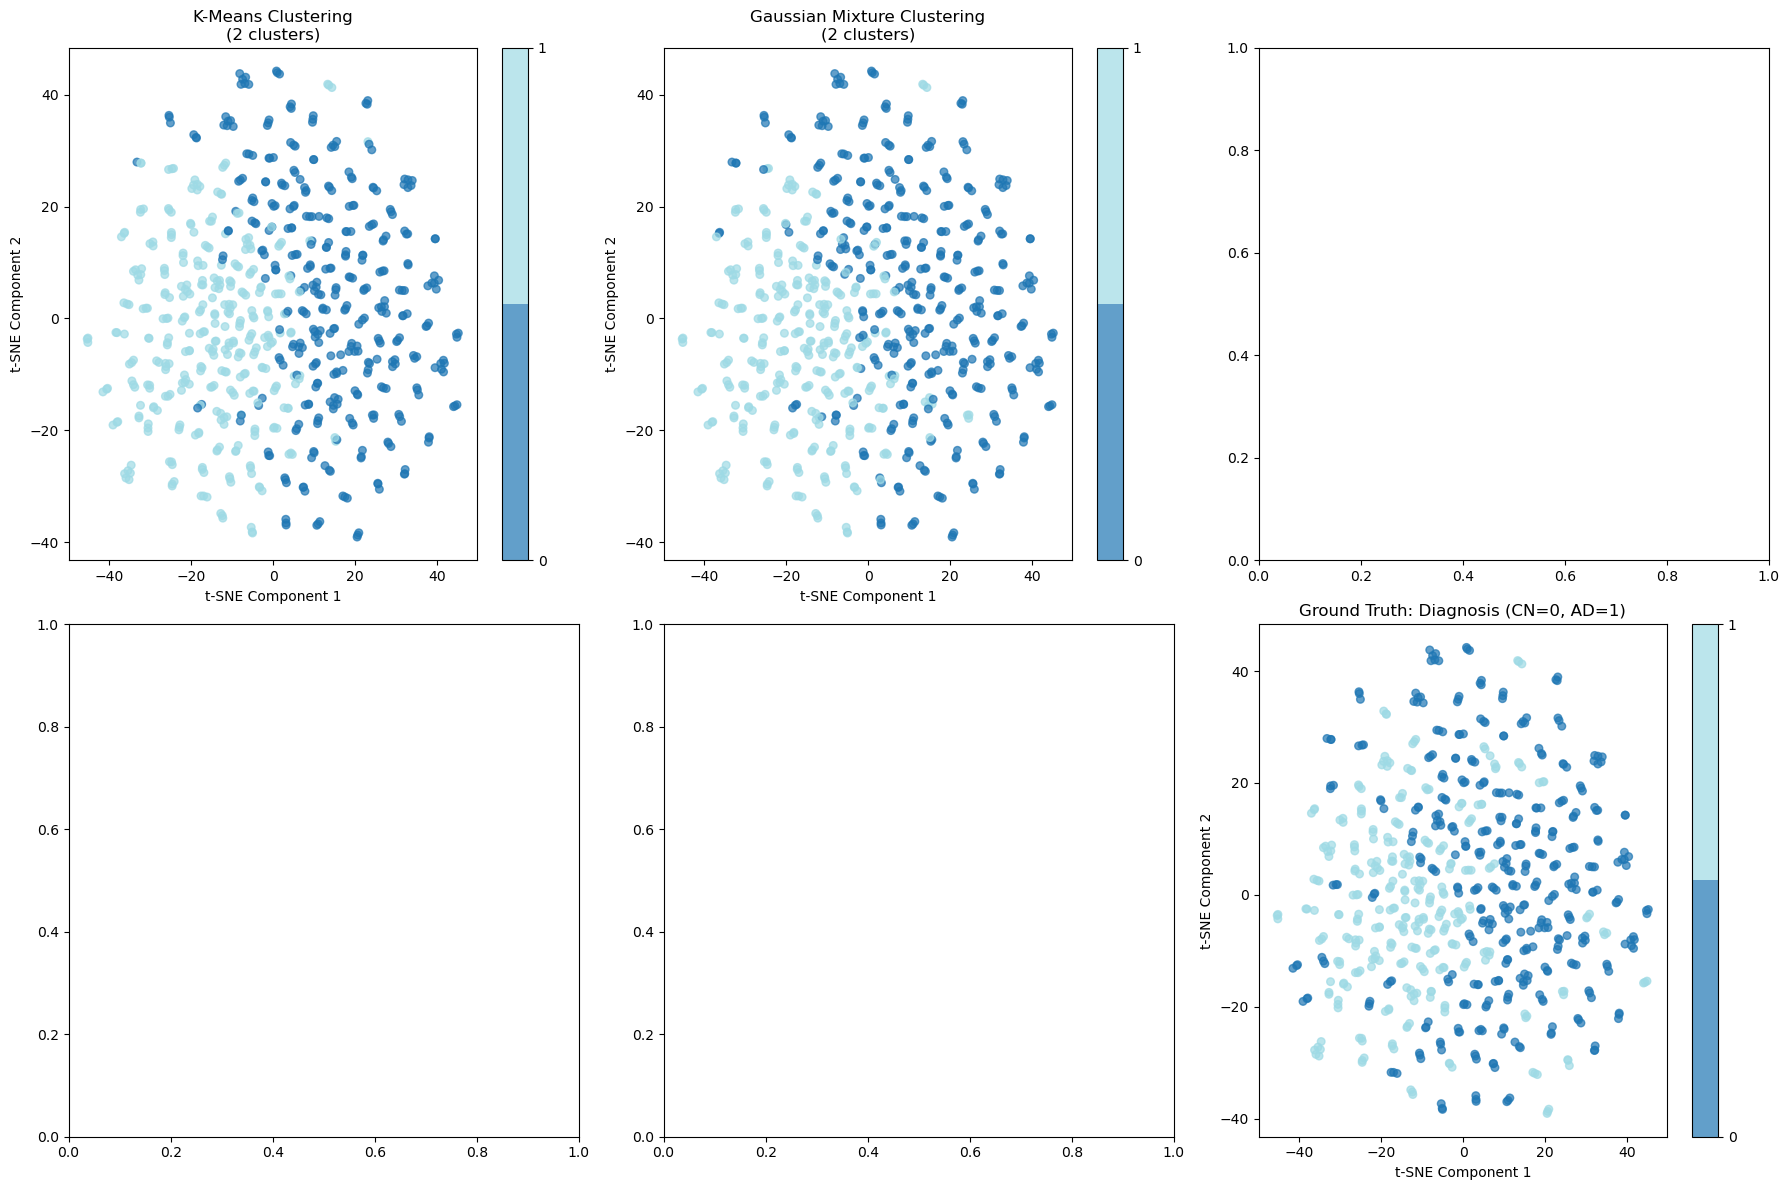

In [20]:
# 6. Visualize clustering results using dimensionality reduction
print('\n6. Visualization of Clustering Results:')

import numpy as np

embedding_label = 'UMAP'
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print('Using UMAP for visualization')
except Exception as e:
    from sklearn.manifold import TSNE
    embedding_label = 't-SNE'
    print(f'UMAP failed ({e}); using t-SNE for visualization')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_umap = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

methods = ['KMeans_Best', 'GMM_Best', 'DBSCAN_Best', 'Hierarchical_Best', 'Spectral_Best']
method_names = ['K-Means', 'Gaussian Mixture', 'DBSCAN', 'Hierarchical', 'Spectral']

all_labels = []
for method in methods:
    if method in clustering_results:
        all_labels.append(np.asarray(clustering_results[method]))
all_labels.append(np.asarray(diagnosis))

unique_labels = sorted(set(np.concatenate(all_labels)))
if -1 in unique_labels:
    label_order = [-1] + [label for label in unique_labels if label != -1]
else:
    label_order = unique_labels

cmap = plt.get_cmap('tab20', len(label_order))
label_to_index = {label: idx for idx, label in enumerate(label_order)}

def map_labels(labels):
    return np.vectorize(label_to_index.get)(labels)

for i, (method, name) in enumerate(zip(methods, method_names)):
    if method in clustering_results:
        labels = clustering_results[method]
        if method == 'GMM_Best':
            # Swap 0 and 1 for visualization only to align with ground truth colors.
            labels = np.where(labels == 0, 1, np.where(labels == 1, 0, labels))
        color_ids = map_labels(labels)
        scatter = axes[i].scatter(
            X_umap[:, 0], X_umap[:, 1],
            c=color_ids, cmap=cmap,
            vmin=0, vmax=len(label_order) - 1,
            alpha=0.7, s=30
        )
        axes[i].set_title(f'{name} Clustering\n({len(set(labels))} clusters)')
        axes[i].set_xlabel(f'{embedding_label} Component 1')
        axes[i].set_ylabel(f'{embedding_label} Component 2')
        cbar = plt.colorbar(scatter, ax=axes[i], ticks=range(len(label_order)))
        cbar.ax.set_yticklabels(label_order)

gt_colors = map_labels(diagnosis)
scatter = axes[5].scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=gt_colors, cmap=cmap,
    vmin=0, vmax=len(label_order) - 1,
    alpha=0.7, s=30
 )
axes[5].set_title('Ground Truth: Diagnosis (CN=0, AD=1)')
axes[5].set_xlabel(f'{embedding_label} Component 1')
axes[5].set_ylabel(f'{embedding_label} Component 2')
cbar = plt.colorbar(scatter, ax=axes[5], ticks=range(len(label_order)))
cbar.ax.set_yticklabels(label_order)

plt.tight_layout()
plt.savefig('clustering_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# 7. Analyze cluster characteristics
print('\n7. Cluster Analysis:')

best_labels = clustering_results['KMeans_Best']
unique_clusters = sorted(set(best_labels))

print(f'\nAnalyzing K-Means clustering with {len(unique_clusters)} clusters:')

cluster_analysis = {}
for cluster_id in unique_clusters:
    cluster_mask = best_labels == cluster_id

    cluster_diag_ratio = np.mean(diagnosis[cluster_mask] == 1) if np.any(cluster_mask) else float('nan')
    cluster_vol_mean = np.mean(volume[cluster_mask]) if np.any(cluster_mask) else float('nan')
    cluster_vol_std = np.std(volume[cluster_mask]) if np.any(cluster_mask) else float('nan')
    cluster_size = np.sum(cluster_mask)

    cluster_analysis[cluster_id] = {
        'size': cluster_size,
        'ad_ratio': cluster_diag_ratio,
        'volume_mean': cluster_vol_mean,
        'volume_std': cluster_vol_std,
    }

    print(f'Cluster {cluster_id}:')
    print(f'  Size: {cluster_size} samples')
    print(f'  AD ratio: {cluster_diag_ratio:.3f}')
    print(f'  Volume mean±std: {cluster_vol_mean:.3f}±{cluster_vol_std:.3f}')

# 8. Create new labels from clustering
print('\n8. Creating Training Labels from Clusters:')

cluster_labels_for_training = best_labels
np.save('unsupervised_cluster_labels.npy', cluster_labels_for_training)
print("Saved cluster labels to 'unsupervised_cluster_labels.npy'")
print(f'Shape: {cluster_labels_for_training.shape}')
print(f'Unique clusters: {sorted(set(cluster_labels_for_training))}')



7. Cluster Analysis:

Analyzing K-Means clustering with 2 clusters:
Cluster 0:
  Size: 363 samples
  AD ratio: 0.135
  Volume mean±std: 2196.895±268.564
Cluster 1:
  Size: 333 samples
  AD ratio: 0.763
  Volume mean±std: 1505.114±262.655

8. Creating Training Labels from Clusters:
Saved cluster labels to 'unsupervised_cluster_labels.npy'
Shape: (696,)
Unique clusters: [0, 1]


In [22]:
# 9. Map cluster IDs to diagnosis labels (CN/AD)
print('\n9. Cluster-to-Diagnosis Mapping:')

def summarize_cluster_labels(labels, diagnosis):
    mapping = {}
    unique_clusters = sorted(set(labels))
    for cluster_id in unique_clusters:
        mask = labels == cluster_id
        cn_count = int((diagnosis[mask] == 0).sum())
        ad_count = int((diagnosis[mask] == 1).sum())
        total = cn_count + ad_count
        if total == 0:
            majority_label = 'N/A'
            majority_ratio = float('nan')
        else:
            majority_label = 'AD' if ad_count >= cn_count else 'CN'
            majority_ratio = max(ad_count, cn_count) / total
        mapping[cluster_id] = {
            'size': total,
            'cn': cn_count,
            'ad': ad_count,
            'majority_label': majority_label,
            'majority_ratio': majority_ratio,
        }
        print(f'  Cluster {cluster_id}: CN={cn_count}, AD={ad_count}, '
              f'majority={majority_label} ({majority_ratio:.2%})')

    total_correct = sum(max(stats['cn'], stats['ad']) for stats in mapping.values())
    total = sum(stats['size'] for stats in mapping.values())
    if total > 0:
        print(f'  Purity (majority-vote accuracy): {total_correct / total:.3%}')
    return mapping

# Evaluate all available clustering methods
for method_name, labels in clustering_results.items():
    print(f'\nMethod: {method_name}')
    summarize_cluster_labels(labels, diagnosis)



9. Cluster-to-Diagnosis Mapping:

Method: KMeans_3
  Cluster 0: CN=199, AD=44, majority=CN (81.89%)
  Cluster 1: CN=46, AD=209, majority=AD (81.96%)
  Cluster 2: CN=148, AD=50, majority=CN (74.75%)
  Purity (majority-vote accuracy): 79.885%

Method: KMeans_Best
  Cluster 0: CN=314, AD=49, majority=CN (86.50%)
  Cluster 1: CN=79, AD=254, majority=AD (76.28%)
  Purity (majority-vote accuracy): 81.609%

Method: GMM_Best
  Cluster 0: CN=66, AD=237, majority=AD (78.22%)
  Cluster 1: CN=327, AD=66, majority=CN (83.21%)
  Purity (majority-vote accuracy): 81.034%



10. Creating pseudo labels from GMM_Best clusters...
Cluster 0: AD ratio = 0.790
Cluster 1: AD ratio = 0.150
Assigning AD to cluster 0, CN to cluster 1
Saved pseudo labels to /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
Pseudo CN volume mean±std: 2177.6926±273.6919
Pseudo AD volume mean±std: 1477.6985±248.3089


/tmp/ipykernel_2776170/3621281693.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


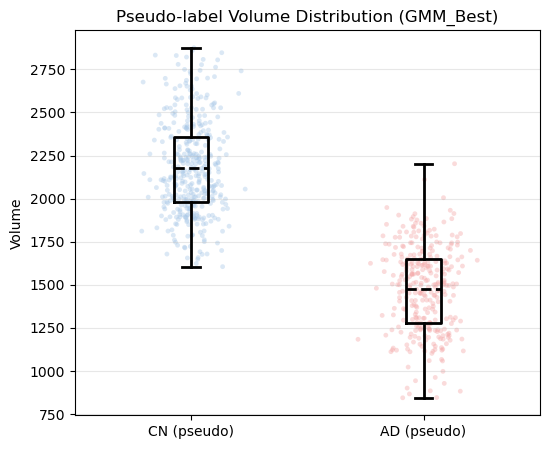

In [42]:
# 10. Create pseudo labels from GMM_Best clusters and analyze volume
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

print('\n10. Creating pseudo labels from GMM_Best clusters...')

if 'GMM_Best' not in clustering_results:
    print('GMM_Best not found in clustering_results.')
else:
    gmm_labels = clustering_results['GMM_Best']
    if len(gmm_labels) != len(valid_filenames):
        print(f'Warning: label count mismatch: {len(gmm_labels)} vs {len(valid_filenames)}')

    diag_mask = diagnosis >= 0
    cluster_ids = sorted(set(gmm_labels))
    cluster_ad_ratio = {}
    for cid in cluster_ids:
        mask = (gmm_labels == cid) & diag_mask
        if np.any(mask):
            cluster_ad_ratio[cid] = np.mean(diagnosis[mask] == 1)
        else:
            cluster_ad_ratio[cid] = float('nan')
        print(f'Cluster {cid}: AD ratio = {cluster_ad_ratio[cid]:.3f}')

    valid_ratios = {cid: r for cid, r in cluster_ad_ratio.items() if np.isfinite(r)}
    if not valid_ratios:
        print('No valid diagnosis labels to map clusters.')
    else:
        ad_cluster = max(valid_ratios, key=valid_ratios.get)
        cn_cluster = min(valid_ratios, key=valid_ratios.get)
        print(f'Assigning AD to cluster {ad_cluster}, CN to cluster {cn_cluster}')

        pseudo_diag = np.full(len(gmm_labels), -1, dtype=int)
        pseudo_diag[gmm_labels == ad_cluster] = 1
        pseudo_diag[gmm_labels == cn_cluster] = 0

        other_clusters = [c for c in cluster_ids if c not in (ad_cluster, cn_cluster)]
        if other_clusters:
            print(f'Warning: more than 2 clusters, assigning CN to clusters {other_clusters}')
            for c in other_clusters:
                pseudo_diag[gmm_labels == c] = 0

        if os.path.exists(labels_path):
            pseudo_labels = {}
            for idx, filename in enumerate(valid_filenames):
                base_name = os.path.splitext(os.path.basename(filename))[0]
                if base_name not in label_map:
                    print(f'Warning: No label found for {base_name}')
                    continue
                label = label_map[base_name]
                if isinstance(label, torch.Tensor):
                    label_tensor = label.clone()
                else:
                    label_tensor = torch.tensor(label, dtype=torch.float32)

                if label_tensor.ndim == 0:
                    label_tensor = label_tensor.view(1)
                label_tensor = label_tensor.view(-1)

                # [pseudo_diag, real_diag, age, sex, volume, ...]
                pseudo_value = torch.tensor(pseudo_diag[idx], dtype=label_tensor.dtype)
                pseudo_label = torch.cat([pseudo_value.view(1), label_tensor], dim=0)
                pseudo_labels[base_name] = pseudo_label

            pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
            torch.save(pseudo_labels, pseudo_path)
            print(f'Saved pseudo labels to {pseudo_path}')
        else:
            print(f'labels.pt not found at {labels_path}; cannot save pseudo labels.')

        if 'pseudo_labels' in locals():
            pseudo_diag_list = []
            pseudo_volumes = []
            for filename in valid_filenames:
                base_name = os.path.splitext(os.path.basename(filename))[0]
                if base_name in pseudo_labels:
                    lbl = pseudo_labels[base_name]
                    pseudo_diag_list.append(int(lbl[0].item()))
                    if lbl.numel() > 4:
                        pseudo_volumes.append(float(lbl[4].item()))
                    else:
                        pseudo_volumes.append(float('nan'))
                else:
                    pseudo_diag_list.append(-1)
                    pseudo_volumes.append(float('nan'))

            pseudo_diag_arr = np.array(pseudo_diag_list)
            pseudo_vol_arr = np.array(pseudo_volumes, dtype=float)

            vol_mask = np.isfinite(pseudo_vol_arr)
            cn_mask = (pseudo_diag_arr == 0) & vol_mask
            ad_mask = (pseudo_diag_arr == 1) & vol_mask

            cn_vol = pseudo_vol_arr[cn_mask]
            ad_vol = pseudo_vol_arr[ad_mask]

            if cn_vol.size > 0:
                print(f'Pseudo CN volume mean±std: {np.mean(cn_vol):.4f}±{np.std(cn_vol):.4f}')
            if ad_vol.size > 0:
                print(f'Pseudo AD volume mean±std: {np.mean(ad_vol):.4f}±{np.std(ad_vol):.4f}')

            plt.figure(figsize=(6, 5))
            box = plt.boxplot(
                [cn_vol, ad_vol],
                labels=['CN (pseudo)', 'AD (pseudo)'],
                showfliers=True,
                showmeans=True,
                meanline=True,
                boxprops={'linewidth': 2},
                whiskerprops={'linewidth': 2},
                capprops={'linewidth': 2},
                medianprops={'color': 'none', 'linewidth': 0},
                meanprops={'color': 'black', 'linewidth': 2},
            )
            jitter = 0.08
            if cn_vol.size > 0:
                plt.scatter(
                    np.random.normal(1, jitter, size=cn_vol.size),
                    cn_vol,
                    s=12, alpha=0.4, color='#A7C7E7', edgecolors='none'
                )
            if ad_vol.size > 0:
                plt.scatter(
                    np.random.normal(2, jitter, size=ad_vol.size),
                    ad_vol,
                    s=12, alpha=0.4, color='#F4A6A6', edgecolors='none'
                )
            plt.ylabel('Volume')
            plt.title('Pseudo-label Volume Distribution (GMM_Best)')
            plt.grid(True, axis='y', alpha=0.3)
            plt.show()


In [40]:
# 11. Unsupervised HLLE+ICA component ranking (stability + reconstruction impact)
if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')

if 'best_params' in globals() and best_params is not None:
    n_neighbors = best_params[0]
    n_components = best_params[1]
else:
    n_neighbors = 300
    n_components = 4
    print('best_params not found; using defaults.')

hlle_full = LocallyLinearEmbedding(
    n_neighbors=n_neighbors,
    n_components=n_components,
    method='hessian',
    eigen_solver='dense'
)
Z_full = hlle_full.fit_transform(X)

ica_full = FastICA(n_components=n_components, random_state=42)
Y_full = ica_full.fit_transform(Z_full)

Z_recon_full = ica_full.inverse_transform(Y_full)
mse_full = np.mean((Z_full - Z_recon_full) ** 2)

impact = []
for i in range(n_components):
    Y_mask = Y_full.copy()
    Y_mask[:, i] = 0.0
    Z_recon = ica_full.inverse_transform(Y_mask)
    mse_i = np.mean((Z_full - Z_recon) ** 2)
    impact.append(mse_i - mse_full)
impact = np.asarray(impact)

n_boot = 5
sample_frac = 0.8
rng = np.random.default_rng(42)
stability_scores = np.zeros(n_components)
valid_runs = 0

def _safe_corr(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return 0.0
    a = a[mask]
    b = b[mask]
    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0
    return abs(np.corrcoef(a, b)[0, 1])

def _greedy_match(corr):
    corr = corr.copy()
    matched = [-1] * n_components
    used_rows = set()
    used_cols = set()
    for _ in range(n_components):
        max_val = -np.inf
        max_r = -1
        max_c = -1
        for r in range(n_components):
            if r in used_rows:
                continue
            for c in range(n_components):
                if c in used_cols:
                    continue
                val = corr[r, c]
                if val > max_val:
                    max_val = val
                    max_r = r
                    max_c = c
        if max_r == -1:
            break
        matched[max_r] = max_c
        used_rows.add(max_r)
        used_cols.add(max_c)
    return matched

for b in range(n_boot):
    idx = rng.choice(X.shape[0], size=int(X.shape[0] * sample_frac), replace=True)
    n_neighbors_b = min(n_neighbors, len(idx) - 1)
    if n_neighbors_b < 2:
        continue
    try:
        hlle_b = LocallyLinearEmbedding(
            n_neighbors=n_neighbors_b,
            n_components=n_components,
            method='hessian',
            eigen_solver='dense'
        )
        Z_b = hlle_b.fit_transform(X[idx])
        ica_b = FastICA(n_components=n_components, random_state=42 + b)
        Y_b = ica_b.fit_transform(Z_b)

        corr = np.zeros((n_components, n_components))
        for i in range(n_components):
            for j in range(n_components):
                corr[i, j] = _safe_corr(Y_full[idx, i], Y_b[:, j])

        matched = _greedy_match(corr)
        for i, j in enumerate(matched):
            if j >= 0:
                stability_scores[i] += corr[i, j]
        valid_runs += 1
    except Exception as e:
        print(f'Bootstrap {b} failed: {e}')

if valid_runs > 0:
    stability_scores /= valid_runs
else:
    stability_scores[:] = np.nan

def _normalize(x):
    x = np.asarray(x, dtype=float)
    if np.all(np.isnan(x)):
        return x
    min_x = np.nanmin(x)
    max_x = np.nanmax(x)
    if np.isclose(max_x, min_x):
        return np.zeros_like(x)
    return (x - min_x) / (max_x - min_x)

impact_norm = _normalize(impact)
stability_norm = _normalize(stability_scores)
combined = 0.5 * impact_norm + 0.5 * stability_norm

order = np.argsort(-combined)
print('\nUnsupervised HLLE+ICA component ranking (higher is more significant):')
for rank, i in enumerate(order, 1):
    print(f'{rank}. component_{i}: stability={stability_scores[i]:.3f}, impact={impact[i]:.6f}, score={combined[i]:.3f}')

unsupervised_scores = {
    'stability': stability_scores,
    'impact': impact,
    'combined': combined,
    'order': order,
    'n_neighbors': n_neighbors,
    'n_components': n_components,
    'n_boot': n_boot,
    'sample_frac': sample_frac,
}



Unsupervised HLLE+ICA component ranking (higher is more significant):
1. component_2: stability=0.942, impact=0.000359, score=0.500
2. component_1: stability=0.930, impact=0.000359, score=0.482
3. component_3: stability=0.897, impact=0.000359, score=0.428
4. component_0: stability=0.631, impact=0.000359, score=0.000


In [43]:
# 12. Inspect pseudo_label.pt contents
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'Looking for: {pseudo_path}')
if os.path.exists(pseudo_path):
    pseudo = torch.load(pseudo_path, map_location='cpu')
    print('type:', type(pseudo))
    if isinstance(pseudo, dict):
        keys = list(pseudo.keys())
        print('num_keys:', len(keys))
        print('first_keys:', keys[:5])
        print('\nSample entries:')
        for k in keys[:3]:
            print(k, '->', pseudo[k])
    else:
        print(pseudo)
else:
    print('pseudo_label.pt not found; run the pseudo-label creation cell first.')


Looking for: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
type: <class 'dict'>
num_keys: 696
first_keys: ['ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left', 'ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329_left', 'ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111524597_S32678_I93331_left', 'ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111542738_S15145_I93333_left', 'ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111602660_S24022_I93335_left']

Sample entries:
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left -> tensor([   0.0000,    0.0000,   85.0000,    0.0000, 1995.9200])
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329_left -> tensor([   0.0000,    0.0000,   85.0000,    0.0000, 2010.5260])
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111524597_S32678_I93331_left -> tensor([   0.0000,    0.0000,   86.0000,    

In [44]:
# 12b. Show pseudo_label.pt schema (pseudo + real + metadata)
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'Looking for: {pseudo_path}')
if os.path.exists(pseudo_path):
    pseudo = torch.load(pseudo_path, map_location='cpu')
    if isinstance(pseudo, dict) and pseudo:
        sample_key = next(iter(pseudo))
        sample = pseudo[sample_key]
        field_names = ['pseudo_diag', 'real_diag', 'age', 'sex', 'volume']
        if sample.numel() > len(field_names):
            field_names += [f'field_{i}' for i in range(len(field_names), sample.numel())]
        print('sample:', sample_key)
        print('entry length:', sample.numel())
        for i in range(sample.numel()):
            name = field_names[i] if i < len(field_names) else f'field_{i}'
            val = sample[i].item() if hasattr(sample[i], 'item') else sample[i]
            print(f'{i}: {name} = {val}')
    else:
        print('pseudo_label.pt has no entries or is not a dict.')
else:
    print('pseudo_label.pt not found; run the pseudo-label creation cell first.')


Looking for: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
sample: ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left
entry length: 5
0: pseudo_diag = 0.0
1: real_diag = 0.0
2: age = 85.0
3: sex = 0.0
4: volume = 1995.9200439453125


In [45]:
# 12c. Compare labels.pt vs pseudo_label.pt (real labels)
import numpy as np

labels_path = os.path.join(mesh_root, 'labels.pt')
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'labels.pt: {labels_path}')
print(f'pseudo_label.pt: {pseudo_path}')

if not os.path.exists(labels_path):
    print('labels.pt not found.')
elif not os.path.exists(pseudo_path):
    print('pseudo_label.pt not found.')
else:
    labels_raw = torch.load(labels_path, map_location='cpu')
    pseudo_raw = torch.load(pseudo_path, map_location='cpu')

    if isinstance(labels_raw, dict):
        label_map = labels_raw
    elif hasattr(labels_raw, '__len__') and len(labels_raw) == len(valid_filenames):
        label_map = {}
        for idx, filename in enumerate(valid_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = labels_raw[idx]
    else:
        label_map = {}
        print('labels.pt is not a dict and length does not match filenames.')

    if isinstance(pseudo_raw, dict):
        pseudo_map = pseudo_raw
    else:
        pseudo_map = {}
        print('pseudo_label.pt is not a dict.')

    label_keys = set(label_map.keys())
    pseudo_keys = set(pseudo_map.keys())
    compare_keys = sorted(pseudo_keys)

    total_pseudo = len(compare_keys)
    missing_in_label = len(pseudo_keys - label_keys)

    mismatch_total = 0
    length_mismatch = 0
    value_mismatch = 0

    pseudo_vs_real_mismatch = 0

    for k in compare_keys:
        if k not in label_map:
            continue
        lbl = label_map[k]
        ps = pseudo_map[k]

        lbl_t = torch.as_tensor(lbl).view(-1)
        ps_t = torch.as_tensor(ps).view(-1)

        if ps_t.numel() < lbl_t.numel() + 1:
            mismatch_total += 1
            length_mismatch += 1
            continue

        ps_real = ps_t[1:1 + lbl_t.numel()]
        matches = torch.isclose(lbl_t, ps_real, rtol=1e-4, atol=1e-5, equal_nan=True)
        if not bool(matches.all()):
            mismatch_total += 1
            value_mismatch += 1

        if lbl_t.numel() > 0 and ps_t.numel() > 0:
            if int(lbl_t[0].item()) != int(ps_t[0].item()):
                pseudo_vs_real_mismatch += 1

    if total_pseudo == 0:
        print('No scans in pseudo_label.pt to compare.')
    else:
        mismatch_pct = 100.0 * mismatch_total / total_pseudo
        pseudo_vs_real_pct = 100.0 * pseudo_vs_real_mismatch / total_pseudo
        print(f'Pseudo scans: {total_pseudo}')
        print(f'Missing in labels.pt: {missing_in_label}')
        print(
            f'Mismatched (real labels vs pseudo real labels): {mismatch_total} '
            f'({mismatch_pct:.2f}%)'
        )
        print(
            f'Pseudo diagnosis vs real diagnosis mismatches: {pseudo_vs_real_mismatch} '
            f'({pseudo_vs_real_pct:.2f}%)'
        )
        if length_mismatch or value_mismatch:
            print(f'  length mismatches: {length_mismatch}')
            print(f'  value mismatches: {value_mismatch}')


labels.pt: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/labels.pt
pseudo_label.pt: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files/pseudo_label_gmm.pt
Pseudo scans: 696
Missing in labels.pt: 0
Mismatched (real labels vs pseudo real labels): 0 (0.00%)
Pseudo diagnosis vs real diagnosis mismatches: 123 (17.67%)


In [46]:
# 13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('\n13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings (K=2 fixed):')

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')

if 'clustering_results' not in globals():
    clustering_results = {}

k_fixed = 2

embedding_sources = {
    'PCA': results.get('PCA'),
    'ICA': results.get('ICA'),
    'HLLE+ICA': results.get('HLLE+ICA'),
    'NMF': results.get('NMF'),
    'FA': results.get('FA'),
}

gmm_scores_by_method = {}
gmm_models_by_method = {}

for name, embedding in embedding_sources.items():
    if embedding is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    if not isinstance(embedding, np.ndarray) or embedding.size == 0:
        print(f'{name}: invalid embedding, skipping.')
        continue

    print(f'\n{name}:')
    scaler = StandardScaler()
    X_emb = scaler.fit_transform(embedding)

    gmm = GaussianMixture(n_components=k_fixed, random_state=42)
    labels = gmm.fit_predict(X_emb)
    sil_score = silhouette_score(X_emb, labels) if len(set(labels)) > 1 else -1.0
    aic_score = gmm.aic(X_emb)
    bic_score = gmm.bic(X_emb)

    gmm_scores_by_method[name] = {
        'silhouette': [sil_score],
        'aic': [aic_score],
        'bic': [bic_score],
    }
    gmm_models_by_method[name] = gmm

    key = f'GMM_Best_{name}'
    clustering_results[key] = labels
    print(f'  K={k_fixed}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}')



13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings (K=2 fixed):

PCA:
  K=2: Silhouette=0.174, AIC=7897.9, BIC=8029.7

ICA:
  K=2: Silhouette=0.174, AIC=7897.9, BIC=8029.7

HLLE+ICA:
  K=2: Silhouette=0.184, AIC=7805.3, BIC=7937.1

NMF:
  K=2: Silhouette=0.244, AIC=3789.3, BIC=3921.1

FA:
  K=2: Silhouette=0.175, AIC=7896.2, BIC=8028.0



14. Visualizing GMM clustering + purity (PCA/ICA/HLLE+ICA/NMF/FA):

PCA purity: 0.772
  cluster 0: size=352, purity=0.705, breakdown={0: 104, 1: 248}
  cluster 1: size=344, purity=0.840, breakdown={0: 289, 1: 55}

ICA purity: 0.772
  cluster 0: size=352, purity=0.705, breakdown={0: 104, 1: 248}
  cluster 1: size=344, purity=0.840, breakdown={0: 289, 1: 55}

HLLE+ICA purity: 0.727
  cluster 0: size=323, purity=0.675, breakdown={0: 105, 1: 218}
  cluster 1: size=373, purity=0.772, breakdown={0: 288, 1: 85}

NMF purity: 0.797
  cluster 0: size=372, purity=0.718, breakdown={0: 105, 1: 267}
  cluster 1: size=324, purity=0.889, breakdown={0: 288, 1: 36}

Factor Analysis purity: 0.773
  cluster 0: size=363, purity=0.700, breakdown={0: 109, 1: 254}
  cluster 1: size=333, purity=0.853, breakdown={0: 284, 1: 49}


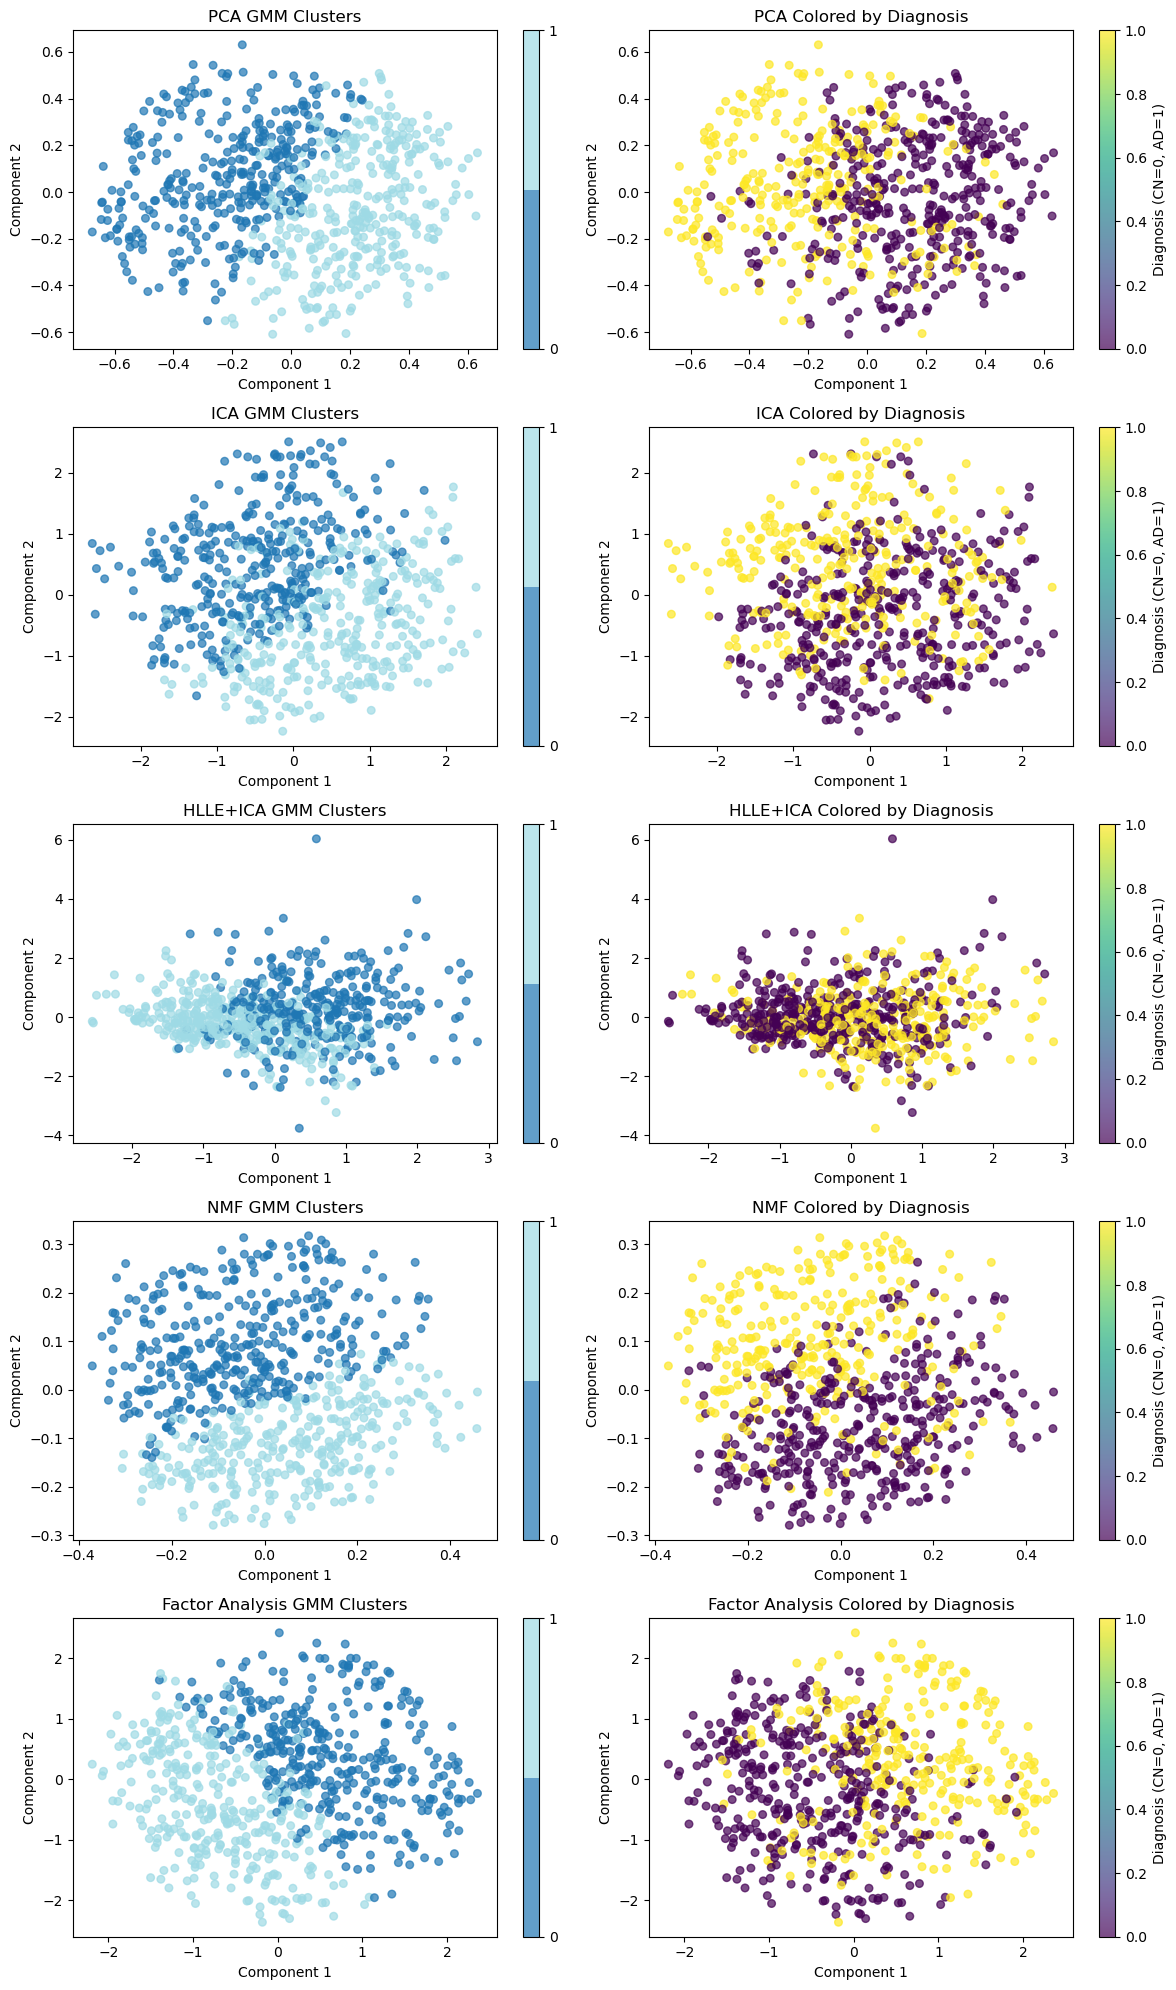

In [47]:
# 14. Visualize GMM clustering results and report purity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print('\n14. Visualizing GMM clustering + purity (PCA/ICA/HLLE+ICA/NMF/FA):')

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'clustering_results' not in globals():
    raise RuntimeError('clustering_results not found. Run the GMM clustering cell first.')
if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found. Run the data loading cell first.')

def _cluster_purity(labels, targets):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets)
    labels = labels[mask]
    targets = targets[mask]
    if labels.size == 0:
        return float('nan'), {}
    purity_sum = 0
    details = {}
    for label in sorted(set(labels)):
        cluster_mask = labels == label
        cluster_targets = targets[cluster_mask]
        if cluster_targets.size == 0:
            continue
        values, counts = np.unique(cluster_targets, return_counts=True)
        major = counts.max()
        purity = major / counts.sum()
        purity_sum += major
        details[int(label)] = {
            'size': int(counts.sum()),
            'purity': float(purity),
            'breakdown': {int(v): int(c) for v, c in zip(values, counts)},
        }
    overall = purity_sum / labels.size if labels.size > 0 else float('nan')
    return overall, details

methods = ['PCA', 'ICA', 'HLLE+ICA', 'NMF', 'FA']
display_names = {
    'PCA': 'PCA',
    'ICA': 'ICA',
    'HLLE+ICA': 'HLLE+ICA',
    'NMF': 'NMF',
    'FA': 'Factor Analysis',
}
method_keys = []
for method in methods:
    key = f'GMM_Best_{method}'
    if key in clustering_results and results.get(method) is not None:
        method_keys.append((method, key))

if not method_keys:
    print('No GMM results found for PCA/ICA/HLLE+ICA/NMF/FA.')
else:
    n_rows = len(method_keys)
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    for row_idx, (method, key) in enumerate(method_keys):
        embedding = results.get(method)
        labels = np.asarray(clustering_results[key])

        if embedding.shape[1] == 1:
            X_vis = np.column_stack([embedding[:, 0], np.zeros(len(embedding))])
        elif embedding.shape[1] == 2:
            X_vis = embedding
        else:
            X_vis = PCA(n_components=2).fit_transform(embedding)

        unique_labels = sorted(set(labels))
        label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
        color_ids = np.vectorize(label_to_index.get)(labels)
        cmap = plt.get_cmap('tab20', max(len(unique_labels), 1))
        method_name = display_names.get(method, method)

        ax_clusters = axes[row_idx, 0]
        sc = ax_clusters.scatter(X_vis[:, 0], X_vis[:, 1], c=color_ids, cmap=cmap, s=30, alpha=0.7)
        ax_clusters.set_title(f'{method_name} GMM Clusters')
        ax_clusters.set_xlabel('Component 1')
        ax_clusters.set_ylabel('Component 2')
        cbar = plt.colorbar(sc, ax=ax_clusters, ticks=range(len(unique_labels)))
        cbar.ax.set_yticklabels(unique_labels)

        ax_diag = axes[row_idx, 1]
        sc2 = ax_diag.scatter(X_vis[:, 0], X_vis[:, 1], c=diagnosis, cmap='viridis', s=30, alpha=0.7)
        ax_diag.set_title(f'{method_name} Colored by Diagnosis')
        ax_diag.set_xlabel('Component 1')
        ax_diag.set_ylabel('Component 2')
        plt.colorbar(sc2, ax=ax_diag, label='Diagnosis (CN=0, AD=1)')

        purity, details = _cluster_purity(labels, diagnosis)
        print(f'\n{method_name} purity: {purity:.3f}')
        for cid in sorted(details):
            info = details[cid]
            print(f"  cluster {cid}: size={info['size']}, purity={info['purity']:.3f}, breakdown={info['breakdown']}")

    plt.tight_layout()
    plt.show()


In [48]:
# 16. High-confidence GMM filtering (purity vs coverage)
import numpy as np
from sklearn.preprocessing import StandardScaler

print('\n16. High-confidence GMM filtering (purity vs coverage):')

if 'gmm_models_by_method' not in globals():
    raise RuntimeError('gmm_models_by_method not found. Run the GMM clustering cell first.')
if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found. Run the label-loading cell first.')

def _cluster_purity(labels, targets):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets) & (targets >= 0)
    labels = labels[mask]
    targets = targets[mask]
    if labels.size == 0:
        return float('nan'), {}
    purity_sum = 0
    details = {}
    for label in sorted(set(labels)):
        cluster_mask = labels == label
        cluster_targets = targets[cluster_mask]
        if cluster_targets.size == 0:
            continue
        values, counts = np.unique(cluster_targets, return_counts=True)
        major = counts.max()
        purity = major / counts.sum()
        purity_sum += major
        details[int(label)] = {
            'size': int(counts.sum()),
            'purity': float(purity),
            'breakdown': {int(v): int(c) for v, c in zip(values, counts)},
        }
    overall = purity_sum / labels.size if labels.size > 0 else float('nan')
    return overall, details

threshold = 0.80  # adjust to trade purity vs coverage

for name, model in gmm_models_by_method.items():
    if model is None:
        print(f'{name}: model missing, skipping.')
        continue
    embedding = results.get(name)
    if embedding is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    scaler = StandardScaler()
    X_emb = scaler.fit_transform(embedding)

    probs = model.predict_proba(X_emb)
    conf = probs.max(axis=1)
    keep = conf >= threshold

    if keep.sum() == 0:
        print(f'{name}: no samples above threshold={threshold:.2f}.')
        continue

    labels = model.predict(X_emb)
    purity, details = _cluster_purity(labels[keep], np.asarray(diagnosis)[keep])
    coverage = float(keep.mean())

    print(f'\n{name}: purity={purity:.3f}, coverage={coverage:.3f} (threshold={threshold:.2f})')
    for cid in sorted(details):
        info = details[cid]
        breakdown = info.get('breakdown', {})
        cn = int(breakdown.get(0, 0))
        ad = int(breakdown.get(1, 0))
        print(f"  cluster {cid}: CN={cn}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")



16. High-confidence GMM filtering (purity vs coverage):

PCA: purity=0.826, coverage=0.786 (threshold=0.80)
  cluster 0: CN=59, AD=219, size=278, purity=0.788
  cluster 1: CN=233, AD=36, size=269, purity=0.866

ICA: purity=0.826, coverage=0.786 (threshold=0.80)
  cluster 0: CN=59, AD=219, size=278, purity=0.788
  cluster 1: CN=233, AD=36, size=269, purity=0.866

HLLE+ICA: purity=0.777, coverage=0.838 (threshold=0.80)
  cluster 0: CN=72, AD=198, size=270, purity=0.733
  cluster 1: CN=255, AD=58, size=313, purity=0.815

NMF: purity=0.829, coverage=0.773 (threshold=0.80)
  cluster 0: CN=68, AD=243, size=311, purity=0.781
  cluster 1: CN=203, AD=24, size=227, purity=0.894

FA: purity=0.813, coverage=0.806 (threshold=0.80)
  cluster 0: CN=69, AD=221, size=290, purity=0.762
  cluster 1: CN=235, AD=36, size=271, purity=0.867


In [49]:
# 17. GMM on full latent codes (X) + purity (with confidence filtering)
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('\n17. GMM on full latent codes (X) + purity (with confidence filtering):')

if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')
if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found. Run the label-loading cell first.')

def _cluster_purity(labels, targets):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets) & (targets >= 0)
    labels = labels[mask]
    targets = targets[mask]
    if labels.size == 0:
        return float('nan'), {}
    purity_sum = 0
    details = {}
    for label in sorted(set(labels)):
        cluster_mask = labels == label
        cluster_targets = targets[cluster_mask]
        if cluster_targets.size == 0:
            continue
        values, counts = np.unique(cluster_targets, return_counts=True)
        major = counts.max()
        purity = major / counts.sum()
        purity_sum += major
        details[int(label)] = {
            'size': int(counts.sum()),
            'purity': float(purity),
            'breakdown': {int(v): int(c) for v, c in zip(values, counts)},
        }
    overall = purity_sum / labels.size if labels.size > 0 else float('nan')
    return overall, details

k_fixed = 2
threshold = 0.90  # adjust to trade purity vs coverage

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gmm_latent = GaussianMixture(n_components=k_fixed, random_state=42)
latent_labels = gmm_latent.fit_predict(X_scaled)
latent_probs = gmm_latent.predict_proba(X_scaled)

sil_score = silhouette_score(X_scaled, latent_labels) if len(set(latent_labels)) > 1 else -1.0
aic_score = gmm_latent.aic(X_scaled)
bic_score = gmm_latent.bic(X_scaled)

purity_all, details_all = _cluster_purity(latent_labels, np.asarray(diagnosis))

print(f'K={k_fixed}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}')
print(f'Purity (all): {purity_all:.3f}')
for cid in sorted(details_all):
    info = details_all[cid]
    breakdown = info.get('breakdown', {})
    cn = int(breakdown.get(0, 0))
    ad = int(breakdown.get(1, 0))
    print(f"  cluster {cid}: CN={cn}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

conf = latent_probs.max(axis=1)
keep = conf >= threshold
if keep.sum() == 0:
    print(f'No samples above threshold={threshold:.2f}.')
else:
    purity_filt, details_filt = _cluster_purity(latent_labels[keep], np.asarray(diagnosis)[keep])
    coverage = float(keep.mean())
    print(f'\nPurity (filtered): {purity_filt:.3f}, coverage={coverage:.3f} (threshold={threshold:.2f})')
    for cid in sorted(details_filt):
        info = details_filt[cid]
        breakdown = info.get('breakdown', {})
        cn = int(breakdown.get(0, 0))
        ad = int(breakdown.get(1, 0))
        print(f"  cluster {cid}: CN={cn}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

gmm_latent_results = {
    'model': gmm_latent,
    'labels': latent_labels,
    'probs': latent_probs,
    'silhouette': sil_score,
    'aic': aic_score,
    'bic': bic_score,
    'purity_all': purity_all,
    'details_all': details_all,
    'threshold': threshold,
}



17. GMM on full latent codes (X) + purity (with confidence filtering):
K=2: Silhouette=0.037, AIC=463460.4, BIC=764839.8
Purity (all): 0.823
  cluster 0: CN=65, AD=245, size=310, purity=0.790
  cluster 1: CN=328, AD=58, size=386, purity=0.850

Purity (filtered): 0.823, coverage=1.000 (threshold=0.90)
  cluster 0: CN=65, AD=245, size=310, purity=0.790
  cluster 1: CN=328, AD=58, size=386, purity=0.850
